# 1. Setup

In [1]:
# Utilities
import time
import warnings
warnings.filterwarnings("ignore")

# Dataframe
import numpy as np
import pandas as pd

# ML: Sklearn
from sklearn.metrics import (accuracy_score,
                             f1_score,
                             roc_auc_score,
                             confusion_matrix,
                             classification_report)

# ML: TabPFN
from tabpfn import TabPFNClassifier

# ML: Torch
import torch

# Explainability
import shap
import pickle
import dice_ml

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.figure_factory as ff
import plotly.express as px
import plotly.io as pio

# Surrogate model for TreeSHAP
from lightgbm import LGBMClassifier

# Saving models
import joblib
import os

print("Core libraries loaded.")

Core libraries loaded.


In [2]:
# Setting up the GPU
if torch.cuda.is_available():
    device = "cuda"
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    device = "cpu"
    print("Using CPU.")

GPU: NVIDIA GeForce RTX 3060 Ti


In [3]:
# Constants
random_state = 8 # Lucky Number
years = ["2020", "2021", "2022", "2024"]

features_const = ["ID", "SEX"]
features = ["AGE", "MARRIED", "CHILD", "HINCOME_group", "JOB_group",
            "Exercise", "HealthyDiet", "Activity", "Interaction_offline",
            "Interaction_online", "Altruistic", "Optimism", "HealthySleep",
            "DeteriorationEconomy", "DeteriorationInteract", "Frustration",
            "CovidAnxiety", "CovidSleepless", "Difficultyliving", "DifficultyWork"]
target = "UCLA"

features_UCLA = ["Sex_Male", "Age", "Is_Married", "Has_Child", "Income", "Income_Missing",
                 "Job_Employed", "Job_Homemaker", "Job_Student", "Job_Unemployed", "Job_Other",
                 "Activity", "Exercise", "Healthy_Diet", "Healthy_Sleep",
                 "Interaction_Offline", "Interaction_Online",
                 "Altruistic", "Frustration", "Optimism",
                 "Covid_Anxiety", "Covid_Sleepless", "Deterioration_Economy", "Deterioration_Interact",
                 "Difficulty_Living", "Difficulty_Work"]
target_UCLA = "UCLA_High"
vars_UCLA = ["ID", "Phase", "Year"]
UCLA_cutoff = 22

print("Constants loaded.")

Constants loaded.


In [4]:
# =====================================================================
# XAI QUICK-RUN CONFIGURATION
# =====================================================================

# Number of background samples for SHAP KernelExplainer
# Debug: 20–50. Full run: 100–200.
N_SHAP_BACKGROUND = 200

# Number of test samples to compute SHAP values for
# Debug: 10–20 (minutes).
N_SHAP_EXPLAIN = 100

# Number of test samples to generate counterfactuals for
# Debug: 3–5 (fast). Full run: 20–50+.
N_CF_SAMPLES = 50

# Number of counterfactual examples to generate per sample
# Debug: 3. Full run: 5–10.
N_CF_PER_SAMPLE = 5

# Number of top features to show in dependence plots
# Debug: 3. Full run: 5–10.
N_TOP_FEATURES = 10

# Batch size for GPU safety
SHAP_BATCH_SIZE = 128

print("XAI runtime configurations loaded.")

XAI runtime configurations loaded.


In [5]:
# Utilities
def format_time(seconds):
    hrs = int(seconds // 3600)
    mins = int((seconds % 3600) // 60)
    secs = seconds % 60
    parts = []
    if hrs: parts.append(f"{hrs}h")
    if mins: parts.append(f"{mins}m")
    parts.append(f"{secs:.2f}s")
    return " ".join(parts)

print("Utilities loaded.")

Utilities loaded.


In [6]:
CATEGORY_LABELS = {
    "Sex_Male": {0: "Female", 1: "Male"},
    "Is_Married": {0: "Unmarried", 1: "Married"},
    "Has_Child": {0: "No Children", 1: "Has Children"},
    "Income": {
        0: "Missing",
        1: "<2.0M JPY",
        2: "2.0-3.9M JPY",
        3: "4.0-5.9M JPY",
        4: "6.0-7.9M JPY",
        5: ">=8.0M JPY"
    },
    "Income_Missing": {0: "Income Reported", 1: "Income Missing"},
    "Job_Employed": {0: "Not Employed", 1: "Employed"},
    "Job_Homemaker": {0: "Not Homemaker", 1: "Homemaker"},
    "Job_Student": {0: "Not Student", 1: "Student"},
    "Job_Unemployed": {0: "Not Unemployed", 1: "Unemployed"},
    "Job_Other": {0: "Not Other Job", 1: "Other Job"},
}

FEATURE_DISPLAY_NAMES = {
    "Sex_Male": "Sex",
    "Age": "Age",
    "Is_Married": "Marital Status",
    "Has_Child": "Has Children",
    "Income": "Household Income",
    "Income_Missing": "Income Missing",
    "Job_Employed": "Employed",
    "Job_Homemaker": "Homemaker",
    "Job_Student": "Student",
    "Job_Unemployed": "Unemployed",
    "Job_Other": "Other Job",
    "Activity": "Social/Physical Activity",
    "Exercise": "Exercise Frequency",
    "Healthy_Diet": "Healthy Diet",
    "Healthy_Sleep": "Healthy Sleep",
    "Interaction_Offline": "Offline Social Interaction",
    "Interaction_Online": "Online Social Interaction",
    "Altruistic": "Altruistic Behavior",
    "Frustration": "Frustration Level",
    "Optimism": "Optimism Level",
    "Covid_Anxiety": "COVID Anxiety",
    "Covid_Sleepless": "COVID-related Sleeplessness",
    "Deterioration_Economy": "Economic Deterioration",
    "Deterioration_Interact": "Social Interaction Deterioration",
    "Difficulty_Living": "Difficulty Living",
    "Difficulty_Work": "Difficulty Working",
}

# Continuous feature scale description (1-7 Likert scale)
LIKERT_FEATURES = [
    "Activity", "Exercise", "Healthy_Diet", "Healthy_Sleep",
    "Interaction_Offline", "Interaction_Online",
    "Altruistic", "Frustration", "Optimism",
    "Covid_Anxiety", "Covid_Sleepless", "Deterioration_Economy",
    "Deterioration_Interact", "Difficulty_Living", "Difficulty_Work"
]

def get_display_name(feat):
    """Get human-readable display name for a feature."""
    return FEATURE_DISPLAY_NAMES.get(feat, feat)

def get_display_names_list(feat_list):
    """Get list of human-readable display names."""
    return [get_display_name(f) for f in feat_list]

def format_feature_value(feat, value):
    """Format a feature value with its category label if applicable."""
    if feat in CATEGORY_LABELS:
        int_val = int(round(value))
        label = CATEGORY_LABELS[feat].get(int_val, str(int_val))
        return f"{label}"
    elif feat in LIKERT_FEATURES:
        return f"{value:.1f}/7"
    elif feat == "Age":
        return f"{value:.0f} years"
    else:
        return f"{value:.2f}"

print("Category mappings loaded.")

Category mappings loaded.


In [7]:
# Output directories
os.makedirs("plots/shap", exist_ok=True)
os.makedirs("plots/counterfactuals", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("explainers", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

print("Output directories created.")

Output directories created.


# 2. Dataset Loading & Preprocessing

In [8]:
DATA_PATH = "../../data/dataset.csv"

df = pd.read_csv(DATA_PATH, na_values=["NA", "N/A", "NaN", "null", "NULL", "", " ", "-"])
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 2659 rows, 106 columns


,ID,SEX,AGE_1,MARRIED_1,CHILD_1,HINCOME_group_1,JOB_group_1,LSNS_group_1,K6_1,PHQ9_1,...,Altruistic_4,Optimism_4,HealthySleep_4,DeteriorationEconomy_4,DeteriorationInteract_4,Frustration_4,CovidAnxiety_4,CovidSleepless_4,Difficultyliving_4,DifficultyWork_4
0,1,1,53,2,2,4.0,1,1,3,8,...,5,4,4,4,3,3,5,5,5,5
1,2,2,66,2,2,5.0,2,0,1,0,...,7,7,7,1,1,1,5,1,1,6
2,3,1,48,1,1,3.0,1,1,3,6,...,1,3,5,4,1,1,1,1,1,1
3,4,1,62,2,2,5.0,1,1,0,0,...,1,5,5,1,1,1,1,1,1,1
4,5,1,59,2,2,5.0,1,0,1,6,...,2,5,5,4,4,4,4,2,4,4


In [9]:
# Reshape longitudinal data
df_prep_list = []
for i, year in enumerate(years, 1):
    current_features = [f"{col}_{i}" for col in features]
    current_target = [f"{col}_{i}" for col in [target]]
    cols_to_select = features_const + current_features + current_target
    temp_df = df[cols_to_select].copy()
    rename_mapping = {f"{col}_{i}": col for col in features + [target]}
    temp_df = temp_df.rename(columns=rename_mapping)
    temp_df["Phase"] = i
    temp_df["Year"] = year
    df_prep_list.append(temp_df)

df_prep = pd.concat(df_prep_list, ignore_index=True)
print(f"Reshaped: {df_prep.shape}")

Reshaped: (10636, 25)


In [10]:
# Handle missing data
missing_values = df_prep.isnull().sum()
missing_percent = 100 * df_prep.isnull().sum() / len(df_prep)
missing_df = pd.DataFrame({"Missing Count": missing_values, "Missing Percentage": missing_percent})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values(by="Missing Count", ascending=False)
if missing_df.empty:
    print("No missing values.")
else:
    display(missing_df)

,Missing Count,Missing Percentage
HINCOME_group,1860,17.487777


In [11]:
# Encode categorical features
df_encoded = df_prep.copy()
df_encoded["Sex_Male"] = (df_encoded["SEX"] == 1).astype(int)
df_encoded["Is_Married"] = (df_encoded["MARRIED"] == 2).astype(int)
df_encoded["Has_Child"] = (df_encoded["CHILD"] == 2).astype(int)
df_encoded["Income_Missing"] = df_encoded["HINCOME_group"].isna().astype(int)
df_encoded["Income"] = df_encoded["HINCOME_group"].fillna(0).astype(int)

job_map = {1: "Job_Employed", 2: "Job_Homemaker", 3: "Job_Student",
           4: "Job_Unemployed", 5: "Job_Other"}
job_labels = df_encoded["JOB_group"].astype("Int64").map(job_map)
job_encoding = pd.get_dummies(job_labels, dtype=int)
df_encoded = pd.concat([df_encoded, job_encoding], axis=1)

df_encoded = df_encoded.rename(columns={
    "AGE": "Age", "HealthyDiet": "Healthy_Diet", "HealthySleep": "Healthy_Sleep",
    "Interaction_offline": "Interaction_Offline", "Interaction_online": "Interaction_Online",
    "CovidAnxiety": "Covid_Anxiety", "CovidSleepless": "Covid_Sleepless",
    "DeteriorationEconomy": "Deterioration_Economy",
    "DeteriorationInteract": "Deterioration_Interact",
    "Difficultyliving": "Difficulty_Living", "DifficultyWork": "Difficulty_Work"
})

df_encoded[target_UCLA] = (df_encoded["UCLA"] >= UCLA_cutoff).astype(int)
df_encoded = df_encoded.drop(columns=["SEX", "MARRIED", "CHILD", "HINCOME_group", "JOB_group", "UCLA"])
df_encoded = df_encoded[vars_UCLA + features_UCLA + [target_UCLA]]
print(f"Encoded: {df_encoded.shape}")
print(f"Target distribution:\n{df_encoded[target_UCLA].value_counts()}")

Encoded: (10636, 30)
Target distribution:
UCLA_High
1    7128
0    3508
Name: count, dtype: int64


# 3. EDA

In [12]:
# Statistical
df_encoded.describe()

,ID,Phase,Sex_Male,Age,Is_Married,Has_Child,Income,Income_Missing,Job_Employed,Job_Homemaker,...,Altruistic,Frustration,Optimism,Covid_Anxiety,Covid_Sleepless,Deterioration_Economy,Deterioration_Interact,Difficulty_Living,Difficulty_Work,UCLA_High
count,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,...,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000
mean,1330.000000,2.500000,0.582926,53.791087,0.644321,0.570985,2.720666,0.174878,0.687759,0.139150,...,5.087909,3.031685,4.112354,3.291087,2.356149,3.493983,2.537890,2.646296,2.796822,0.670177
std,767.623216,1.118087,0.493099,12.784209,0.478741,0.494959,1.737744,0.379880,0.463430,0.346119,...,1.843496,1.683804,1.550914,1.686384,1.472101,1.702638,1.523418,1.641990,1.751135,0.470171
min,1.000000,1.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,665.000000,1.750000,0.000000,45.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,4.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,0.000000
50%,1330.000000,2.500000,1.000000,54.000000,1.000000,1.000000,3.000000,0.000000,1.000000,0.000000,...,5.000000,3.000000,4.000000,4.000000,2.000000,4.000000,2.000000,2.000000,3.000000,1.000000
75%,1995.000000,3.250000,1.000000,63.000000,1.000000,1.000000,4.000000,0.000000,1.000000,0.000000,...,7.000000,4.000000,5.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,1.000000
max,2659.000000,4.000000,1.000000,92.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,...,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,1.000000


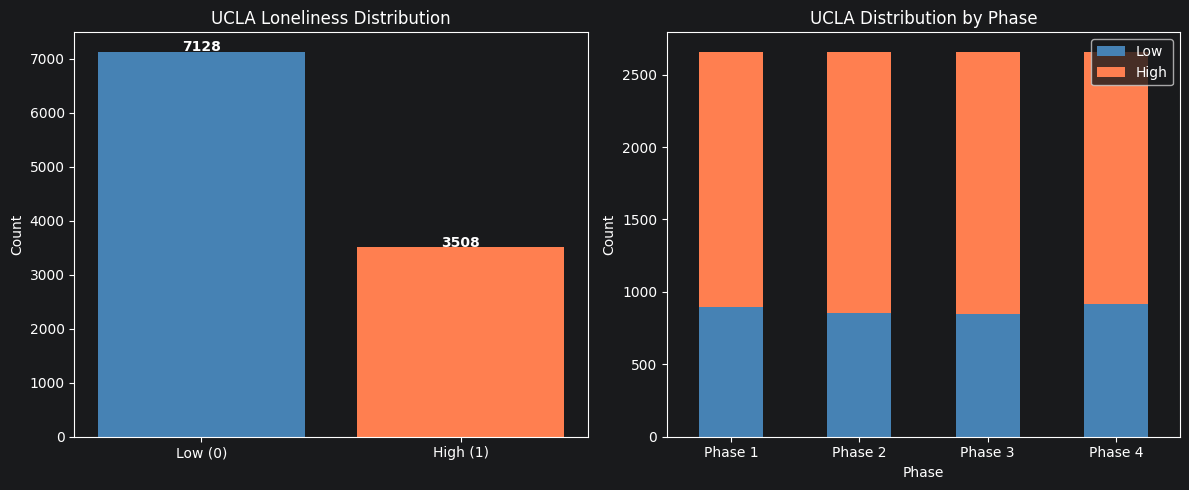

Saved: plots/target_distribution.png


In [13]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df_encoded[target_UCLA].value_counts()
axes[0].bar(["Low (0)", "High (1)"], counts.values, color=["steelblue", "coral"])
axes[0].set_title("UCLA Loneliness Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

phase_target = df_encoded.groupby("Phase")[target_UCLA].value_counts().unstack(fill_value=0)
phase_target.plot(kind="bar", stacked=True, ax=axes[1], color=["steelblue", "coral"])
axes[1].set_title("UCLA Distribution by Phase")
axes[1].set_ylabel("Count")
axes[1].legend(["Low", "High"])
axes[1].set_xticklabels([f"Phase {i}" for i in range(1, 5)], rotation=0)

plt.tight_layout()
plt.savefig("plots/target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/target_distribution.png")

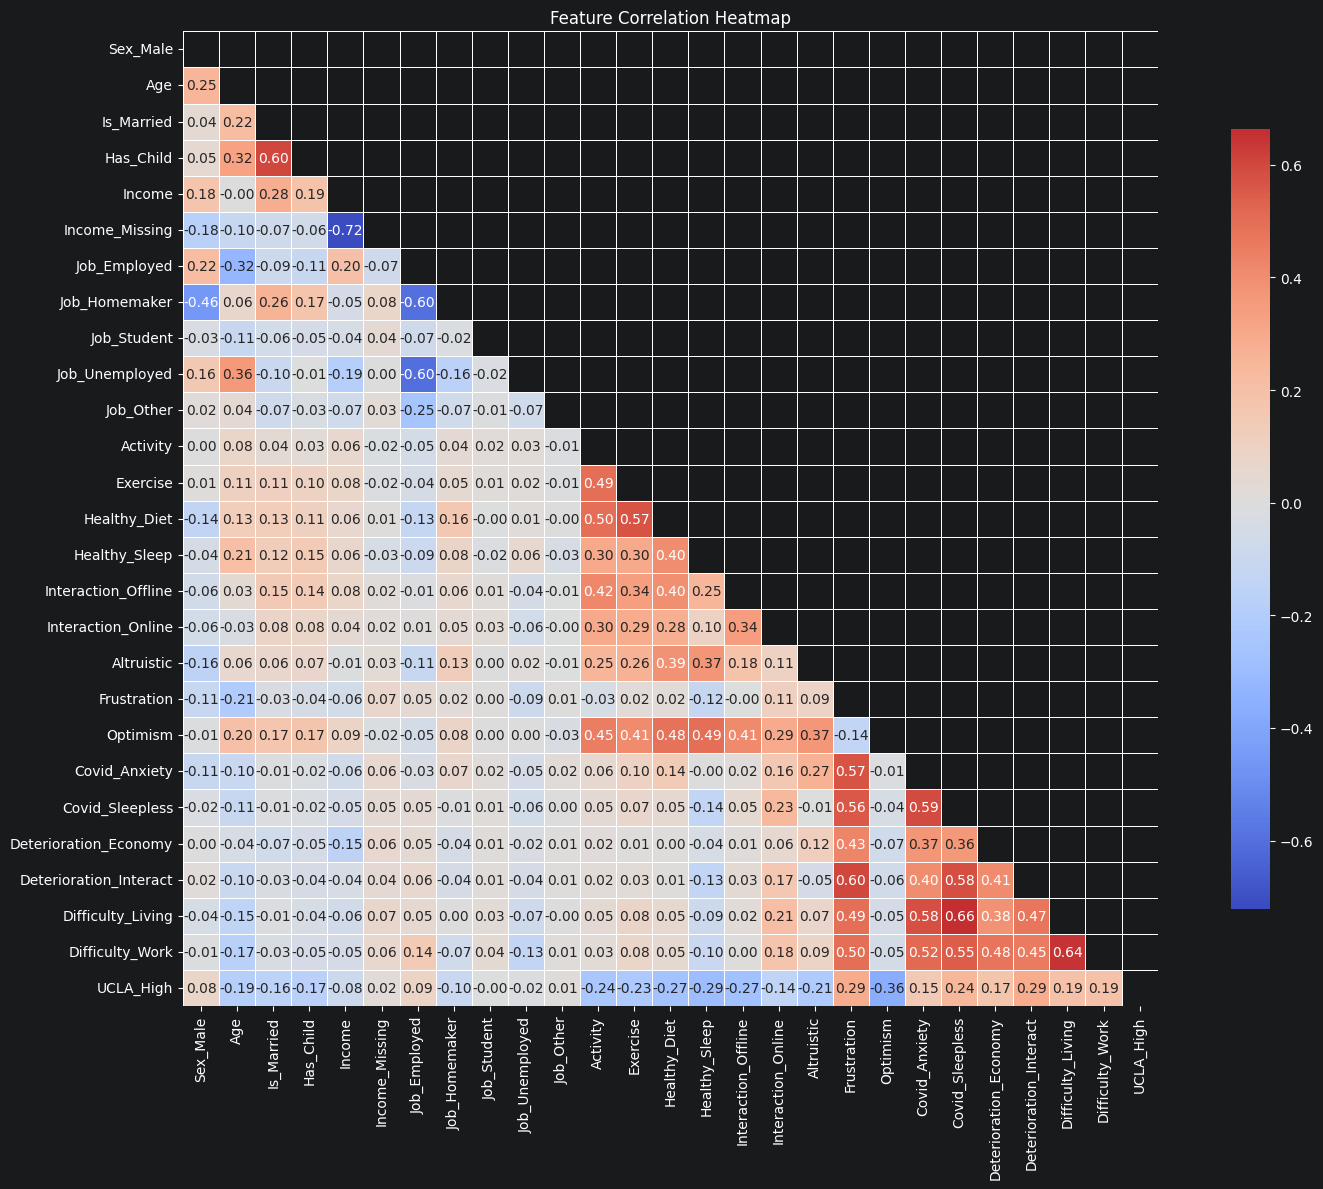

Saved: plots/correlation_heatmap.png


In [14]:
# Correlation heatmap
plt.figure(figsize=(16, 12))
corr = df_encoded[features_UCLA + [target_UCLA]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/correlation_heatmap.png")

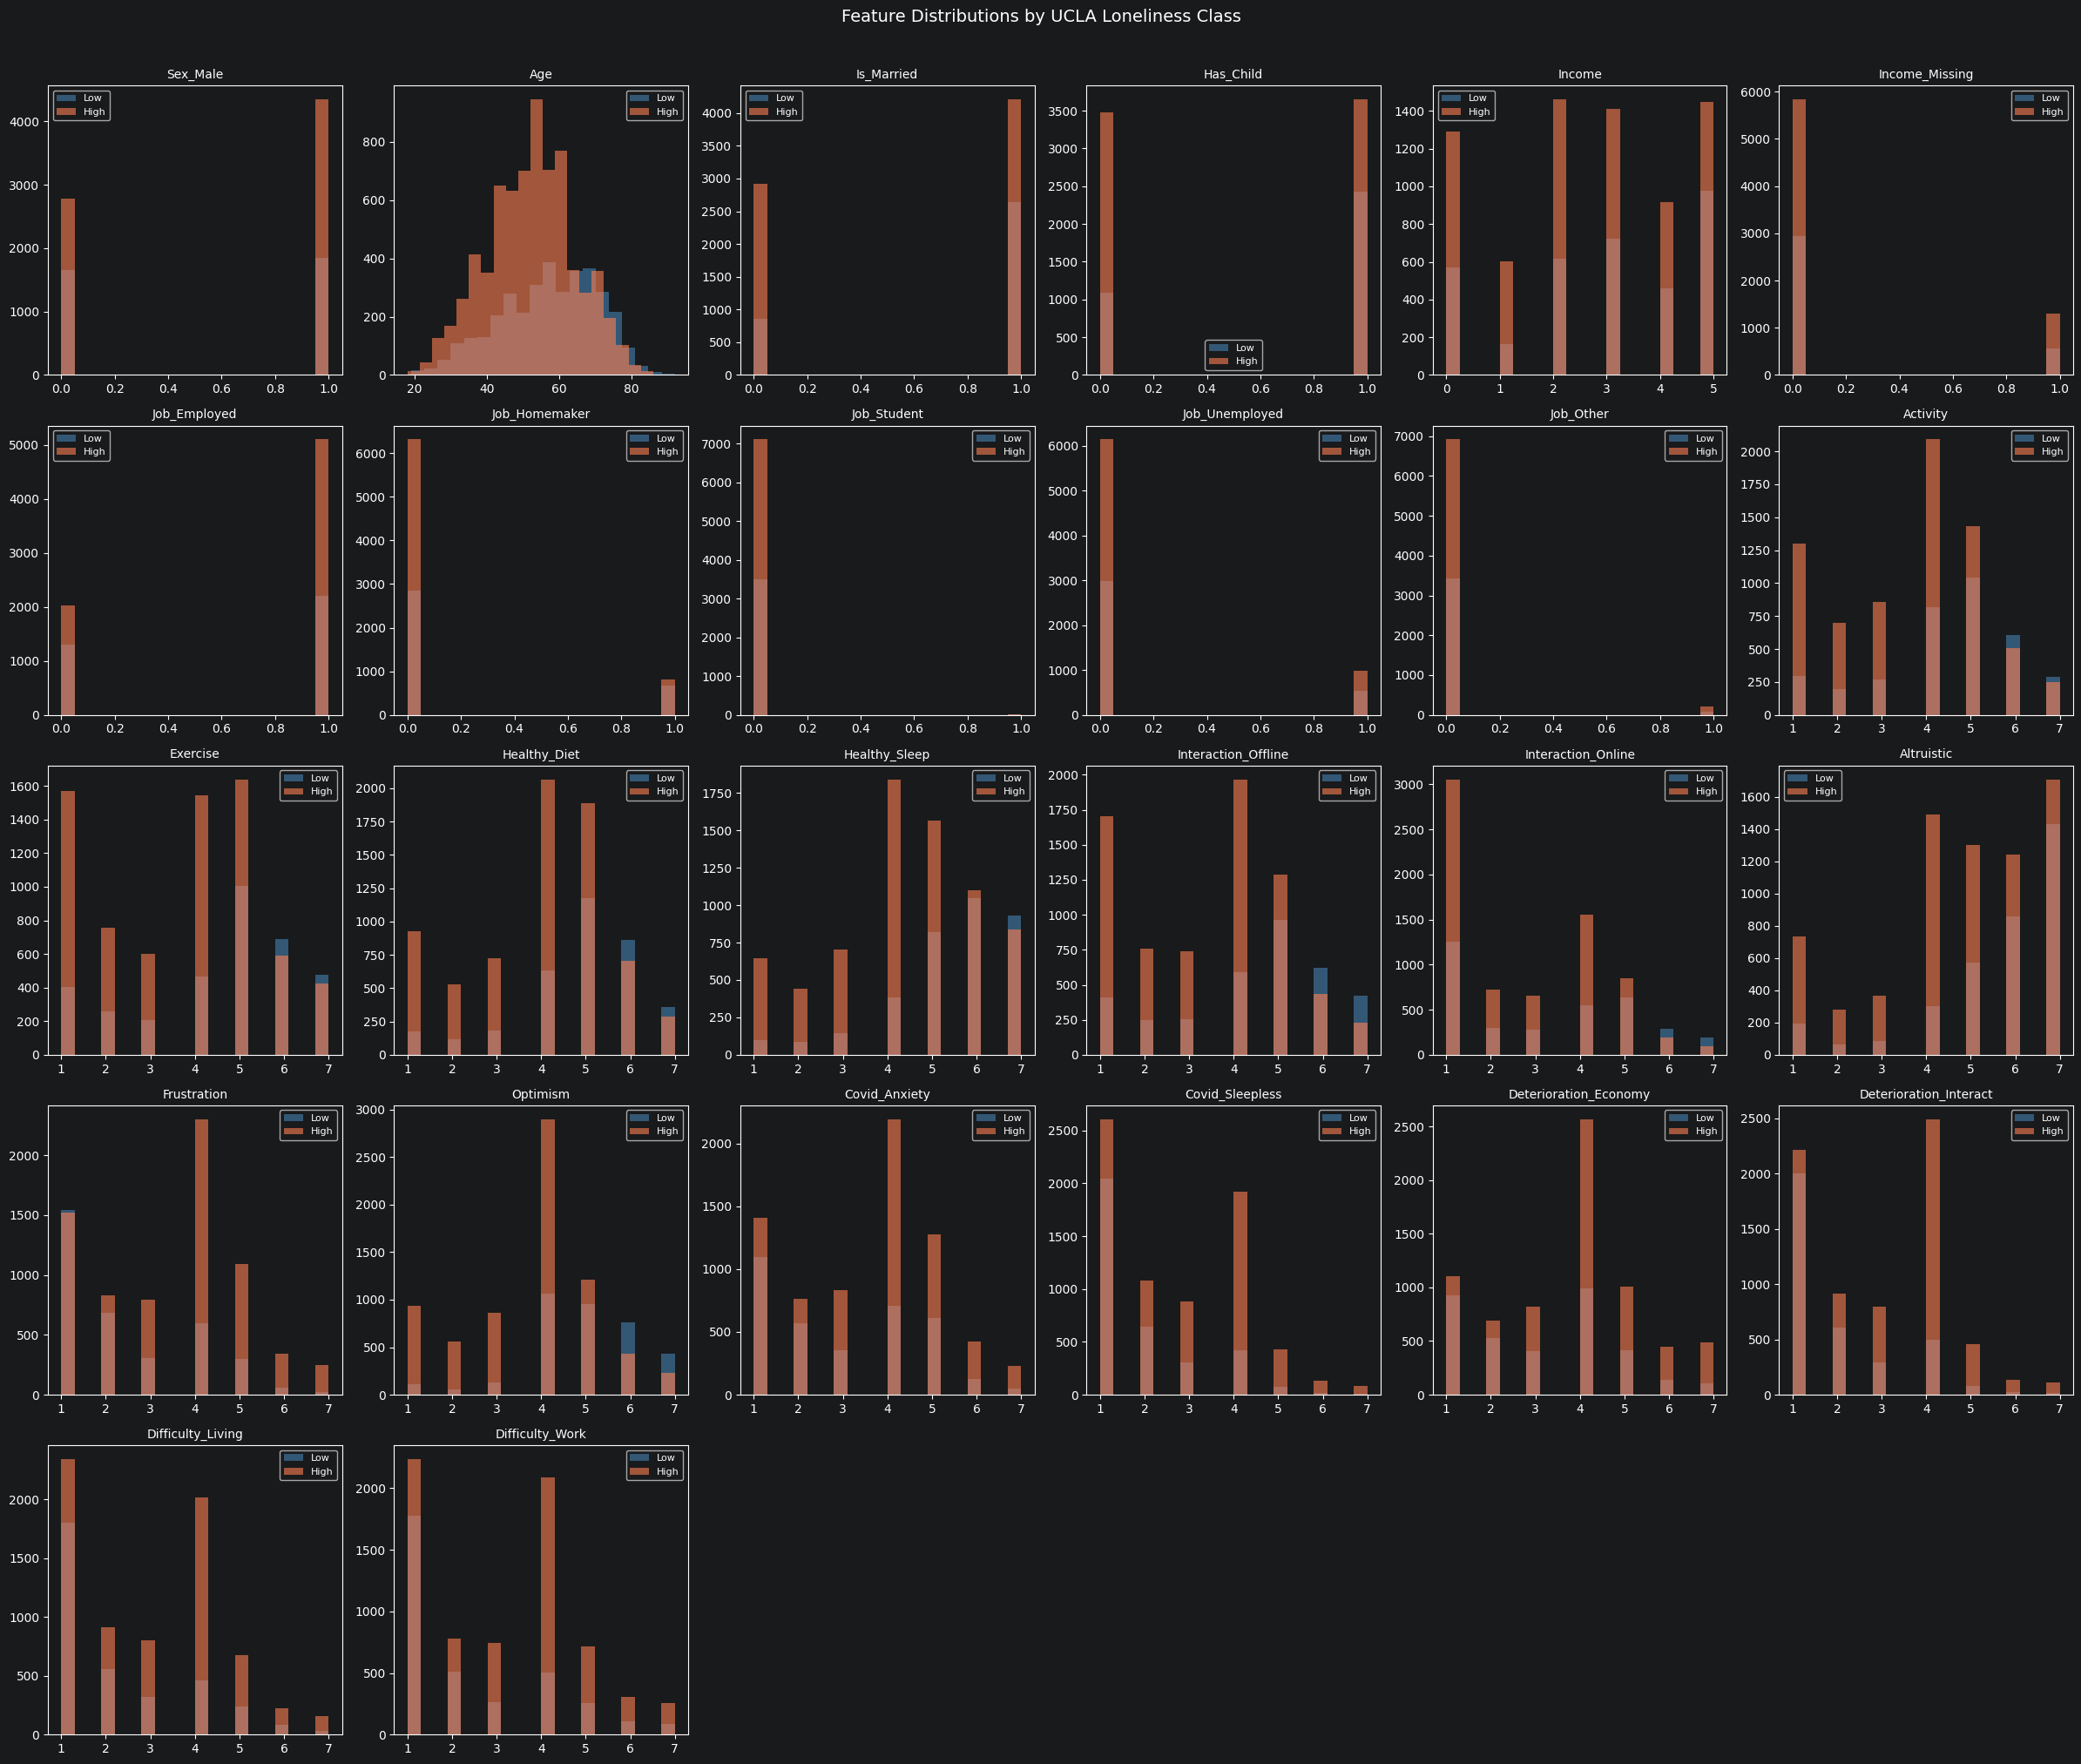

Saved: plots/feature_distributions.png


In [15]:
# Feature distributions by target class
fig, axes = plt.subplots(5, 6, figsize=(24, 20))
axes = axes.flatten()

for i, feat in enumerate(features_UCLA):
    if i < len(axes):
        for label, color in zip([0, 1], ["steelblue", "coral"]):
            subset = df_encoded[df_encoded[target_UCLA] == label][feat]
            axes[i].hist(subset, bins=20, alpha=0.6, color=color,
                        label="Low" if label == 0 else "High")
        axes[i].set_title(feat, fontsize=10)
        axes[i].legend(fontsize=8)

for j in range(len(features_UCLA), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions by UCLA Loneliness Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("plots/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/feature_distributions.png")

# 4. Train-Test Split

In [16]:
df_ml = df_encoded.copy()
df_train = df_ml[df_ml["Phase"].isin([1, 2, 3])].copy()
df_test = df_ml[df_ml["Phase"] == 4].copy()

ignore_feats = vars_UCLA
X_train = df_train.drop(columns=[target_UCLA] + ignore_feats, errors="ignore")
y_train = df_train[target_UCLA]
X_test = df_test.drop(columns=[target_UCLA] + ignore_feats, errors="ignore")
y_test = df_test[target_UCLA]

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing set:  {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Training set: 7977 samples, 26 features
Testing set:  2659 samples, 26 features

Training target distribution:
UCLA_High
1    5382
0    2595
Name: count, dtype: int64

Test target distribution:
UCLA_High
1    1746
0     913
Name: count, dtype: int64


# 5. Baseline Model Training

In [17]:
# Define all models with default hyperparameters
models = [
    ("TabPFN", TabPFNClassifier(device=device, random_state=random_state))
]

In [18]:
# Train and evaluate all baseline models
results = []
trained_models = {}
cm_data = {}

for name, model in models:
    print(f"\n{'='*60}")
    print(f"  {name} (baseline)")
    print(f"{'='*60}")

    # Train
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    # Predict
    start_test = time.time()
    y_pred = model.predict(X_test)
    test_time = time.time() - start_test

    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC AUC:  {auc:.4f}")
    print(f"  Train:    {format_time(train_time)}")
    print(f"  Predict:  {format_time(test_time)}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Low', 'High'])}")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1,
        "ROC AUC": auc,
        "Train Time (s)": train_time,
        "Test Time (s)": test_time
    })

    trained_models[name] = model
    cm_data[name] = confusion_matrix(y_test, y_pred)

df_results = pd.DataFrame(results)
print("\n" + "="*60)
print("  All baseline models trained.")
print("="*60)


  TabPFN (baseline)
  Accuracy: 0.7789
  F1-Score: 0.8397
  ROC AUC:  0.8427
  Train:    0.84s
  Predict:  7.81s

              precision    recall  f1-score   support

         Low       0.72      0.58      0.64       913
        High       0.80      0.88      0.84      1746

    accuracy                           0.78      2659
   macro avg       0.76      0.73      0.74      2659
weighted avg       0.77      0.78      0.77      2659


  All baseline models trained.


# 6. Results & Comparison

In [19]:
# Confusion matrices
for name in cm_data:
    cm = cm_data[name]
    fig_cm = ff.create_annotated_heatmap(
        z=cm.tolist(),
        x=["Predicted Low", "Predicted High"],
        y=["Actual Low", "Actual High"],
        annotation_text=[[str(y) for y in x] for x in cm.tolist()],
        colorscale="Viridis"
    )
    fig_cm.update_layout(title_text=f"Confusion Matrix (Baseline): {name}",
                         yaxis=dict(autorange="reversed"), height=350)
    fig_cm.show()

# 7. Save Models & Results

In [20]:
# Save all models
for name, model in trained_models.items():
    safe_name = name.lower().replace(" ", "_").replace("-", "_")
    save_path = f"models/{safe_name}.joblib"
    joblib.dump(model, save_path)
    print(f"Saved: {save_path}")

# Save results
df_results.to_csv("models/baseline_results.csv", index=False)
print("\nBaseline results saved to models/baseline_results.csv")

# Save training data
X_train.to_csv("artifacts/X_train.csv", index=False)
X_test.to_csv("artifacts/X_test.csv", index=False)
y_train.to_csv("artifacts/y_train.csv", index=False)
y_test.to_csv("artifacts/y_test.csv", index=False)
print("Training/test data saved.")

Saved: models/tabpfn.joblib

Baseline results saved to models/baseline_results.csv
Training/test data saved.


# 8. SHAP Explanations (TreeSHAP via LightGBM Surrogate)

https://arxiv.org/html/2510.08739v1

In [21]:
# Train LightGBM surrogate to mimic TabPFN's predicted probabilities
from lightgbm import LGBMClassifier

print("Building LightGBM surrogate of TabPFN...")
start_time = time.time()

# Get TabPFN's predictions
tabpfn_train_probs = model.predict_proba(X_train)[:, 1]
tabpfn_test_probs = model.predict_proba(X_test)[:, 1]

# Train surrogate to reproduce TabPFN's probability ranking
surrogate_labels_train = (tabpfn_train_probs >= 0.5).astype(int)
surrogate_labels_test = (tabpfn_test_probs >= 0.5).astype(int)

# Try lang sa hyperparameters haha
surrogate = LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=random_state,
    verbose=-1,
)

# Weight samples by how confident TabPFN is (emphasize high-confidence predictions)
weights = np.abs(tabpfn_train_probs - 0.5) + 0.5  # range [0.5, 1.0]
surrogate.fit(X_train, surrogate_labels_train, sample_weight=weights)

# Validate surrogate fidelity
surr_train_probs = surrogate.predict_proba(X_train)[:, 1]
surr_test_probs = surrogate.predict_proba(X_test)[:, 1]

from scipy.stats import spearmanr

# Agreement metrics
train_agreement = (surrogate.predict(X_train) == surrogate_labels_train).mean()
test_agreement = (surrogate.predict(X_test) == surrogate_labels_test).mean()
rank_corr_train, _ = spearmanr(tabpfn_train_probs, surr_train_probs)
rank_corr_test, _ = spearmanr(tabpfn_test_probs, surr_test_probs)

elapsed = time.time() - start_time
print(f"Surrogate trained in {format_time(elapsed)}")
print(f"\nSurrogate fidelity (does it mimic TabPFN?):")
print(f"  Train agreement: {train_agreement:.4f}")
print(f"  Test agreement:  {test_agreement:.4f}")
print(f"  Rank correlation (train): {rank_corr_train:.4f}")
print(f"  Rank correlation (test):  {rank_corr_test:.4f}")

if test_agreement < 0.90:
    print("\nSurrogate fidelity is low...")
else:
    print("\n✓ Surrogate closely mimics TabPFN — TreeSHAP values are reliable.")

Building LightGBM surrogate of TabPFN...
Surrogate trained in 21.16s

Surrogate fidelity (does it mimic TabPFN?):
  Train agreement: 1.0000
  Test agreement:  0.9680
  Rank correlation (train): 0.9736
  Rank correlation (test):  0.9789

✓ Surrogate closely mimics TabPFN — TreeSHAP values are reliable.


In [22]:
# Create TreeExplainer on the surrogate
print("Initializing SHAP TreeExplainer on surrogate...")
start_time = time.time()

shap_explainer = shap.TreeExplainer(surrogate)

elapsed = time.time() - start_time
print(f"TreeExplainer ready in {format_time(elapsed)}")

Initializing SHAP TreeExplainer on surrogate...
TreeExplainer ready in 0.21s


In [23]:
# Compute SHAP values on the test subset — TreeSHAP is exact and fast
X_explain = X_test.iloc[:N_SHAP_EXPLAIN].copy()

print(f"Computing TreeSHAP values for {len(X_explain)} test samples...")
start_time = time.time()

shap_values_raw = shap_explainer.shap_values(X_explain)

elapsed = time.time() - start_time
print(f"SHAP values computed in {format_time(elapsed)}")

# Ensure consistent format for downstream cells
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw  # Already [class0_2d, class1_2d]
    print(f"Shape: class 0 = {shap_values[0].shape}, class 1 = {shap_values[1].shape}")
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    # (n_samples, n_features, n_classes) → list of 2D
    shap_values = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
    print(f"Shape: class 0 = {shap_values[0].shape}, class 1 = {shap_values[1].shape}")
else:
    # Single output (regression-style) — wrap for binary
    shap_values = [-shap_values_raw, shap_values_raw]
    print(f"Shape: {shap_values[0].shape} (mirrored for binary)")

print(f"\nExpected values: {shap_explainer.expected_value}")

Computing TreeSHAP values for 100 test samples...
SHAP values computed in 0.05s
Shape: (100, 26) (mirrored for binary)

Expected values: 5.7749410980532705


In [24]:
# Save SHAP artifacts
with open("explainers/shap_values_test.pkl", "wb") as f:
    pickle.dump(shap_values, f)

# TreeExplainer.expected_value may be a list [ev_class0, ev_class1] or array
expected_value = shap_explainer.expected_value
if isinstance(expected_value, list):
    expected_value = np.array(expected_value)
elif isinstance(expected_value, (int, float)):
    expected_value = np.array([-expected_value, expected_value])

with open("explainers/shap_expected_value.pkl", "wb") as f:
    pickle.dump(expected_value, f)

# Save X_explain so plots can be reproduced without rerunning SHAP
X_explain.to_csv("artifacts/X_explain.csv", index=False)

# Save surrogate model for the dashboard (lighter than TabPFN)
joblib.dump(surrogate, "models/surrogate_lgbm.joblib")

print("SHAP values, expected values, X_explain, and surrogate model saved.")

SHAP values, expected values, X_explain, and surrogate model saved.


## 3.1 Global Feature Importance

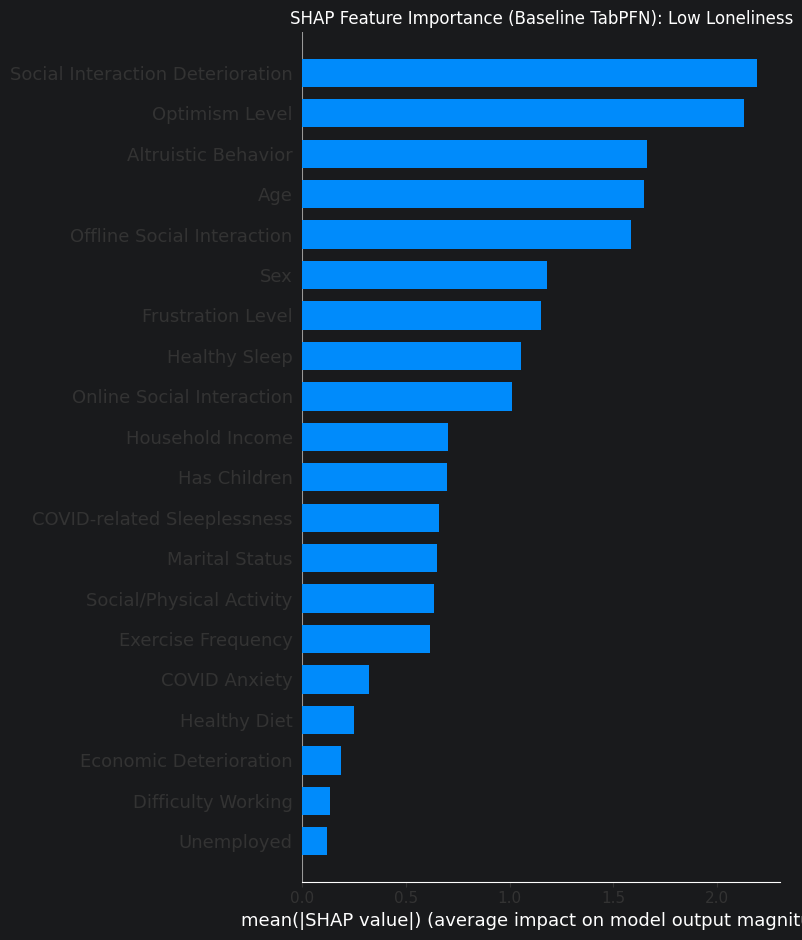

Saved: plots/shap/importance_low_loneliness.png


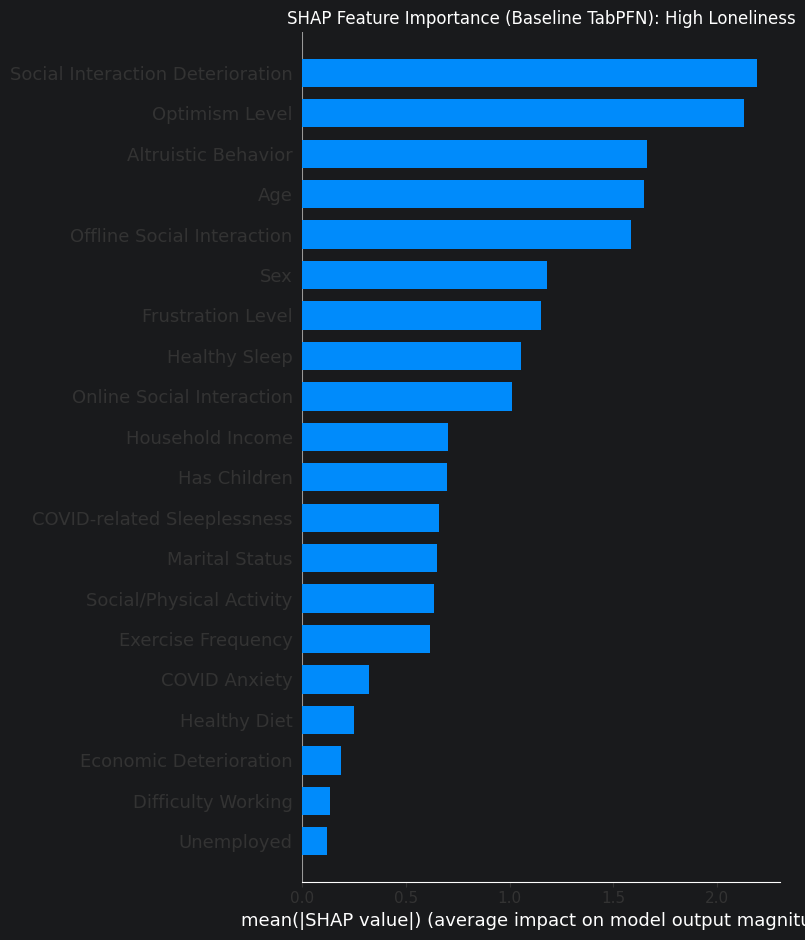

Saved: plots/shap/importance_high_loneliness.png


In [25]:
features_list = X_train.columns.tolist()
display_names_list = get_display_names_list(features_list)
class_names = ["Low Loneliness", "High Loneliness"]

for i, class_name in enumerate(class_names):
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(shap_values[i], X_explain,
                      feature_names=display_names_list, plot_type="bar",
                      show=False, max_display=20)
    plt.title(f"SHAP Feature Importance (Baseline TabPFN): {class_name}")
    plt.tight_layout()
    safe_name = class_name.lower().replace(" ", "_")
    plt.savefig(f"plots/shap/importance_{safe_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: plots/shap/importance_{safe_name}.png")

## 3.2 Feature Effects

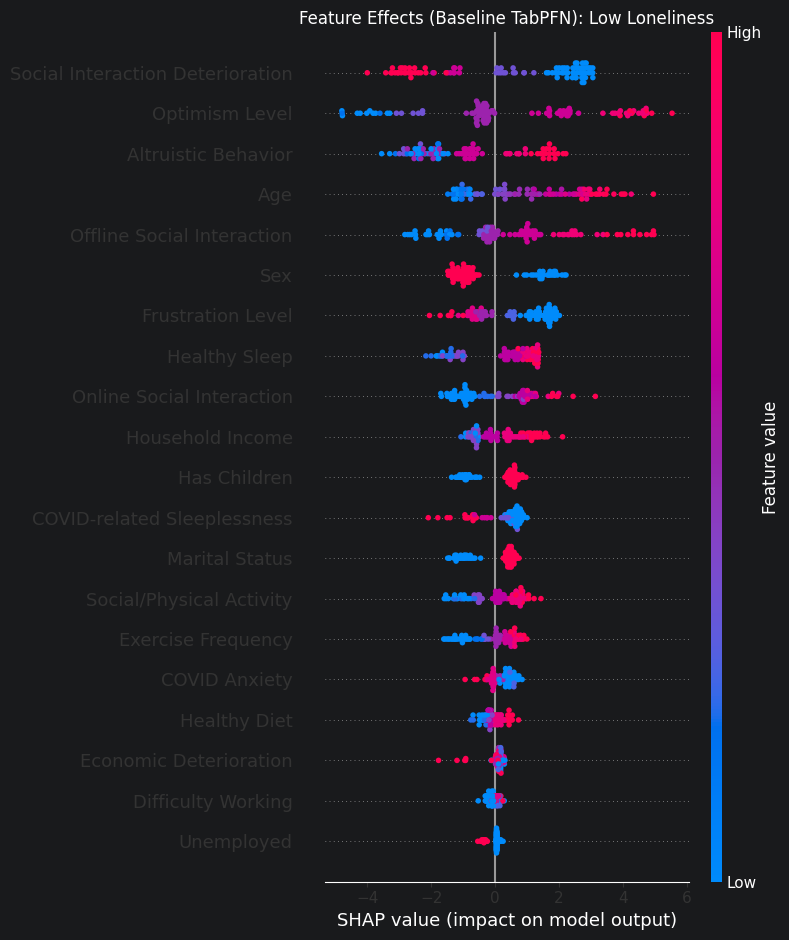

Saved: plots/shap/effects_low_loneliness.png


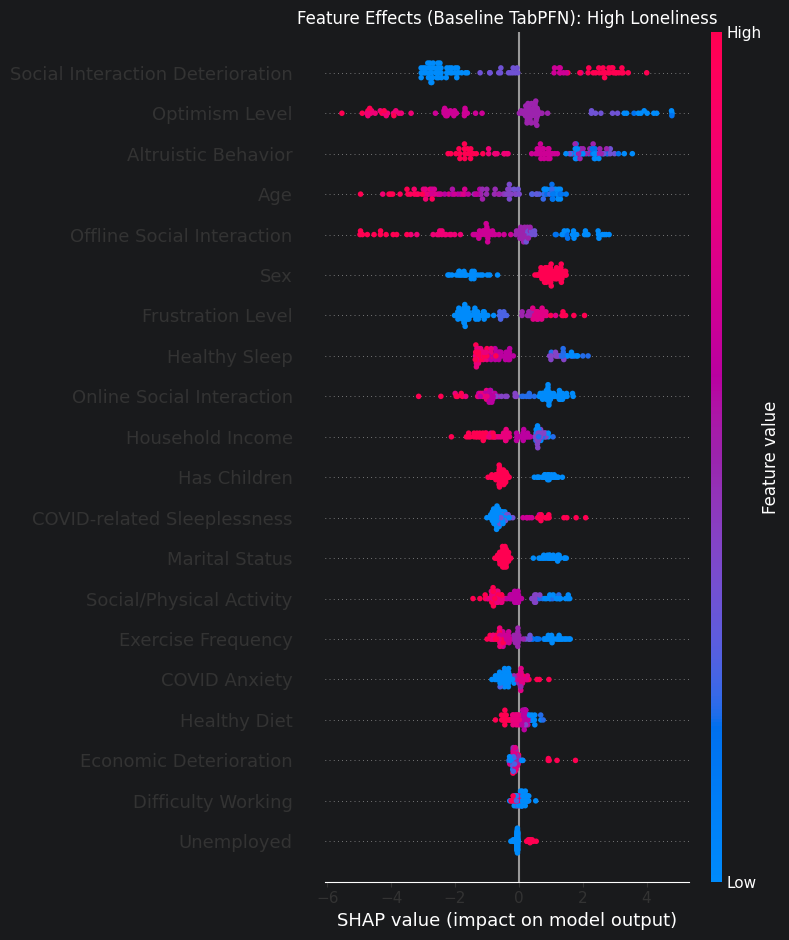

Saved: plots/shap/effects_high_loneliness.png


In [26]:
for i, class_name in enumerate(class_names):
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(shap_values[i], X_explain,
                      feature_names=display_names_list,
                      show=False, max_display=20)
    plt.title(f"Feature Effects (Baseline TabPFN): {class_name}")
    plt.tight_layout()
    safe_name = class_name.lower().replace(" ", "_")
    plt.savefig(f"plots/shap/effects_{safe_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: plots/shap/effects_{safe_name}.png")

## 3.3 Dependence Plots

Top 10 features by mean |SHAP| (High Loneliness):
  1. Social Interaction Deterioration = 2.1963
  2. Optimism Level = 2.1333
  3. Altruistic Behavior = 1.6628
  4. Age = 1.6507
  5. Offline Social Interaction = 1.5874
  6. Sex = 1.1790
  7. Frustration Level = 1.1498
  8. Healthy Sleep = 1.0546
  9. Online Social Interaction = 1.0119
  10. Household Income = 0.7042


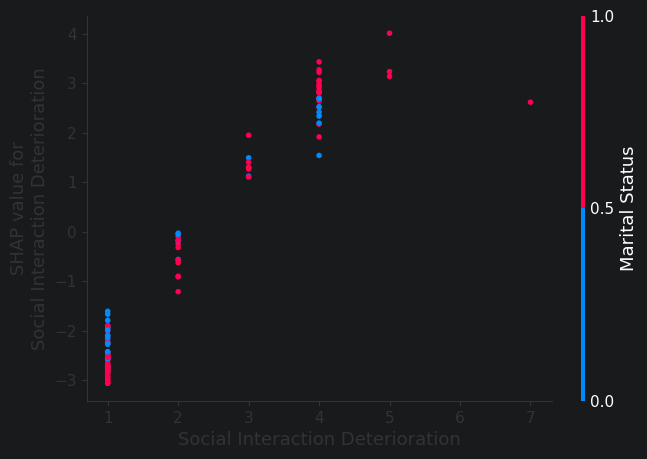

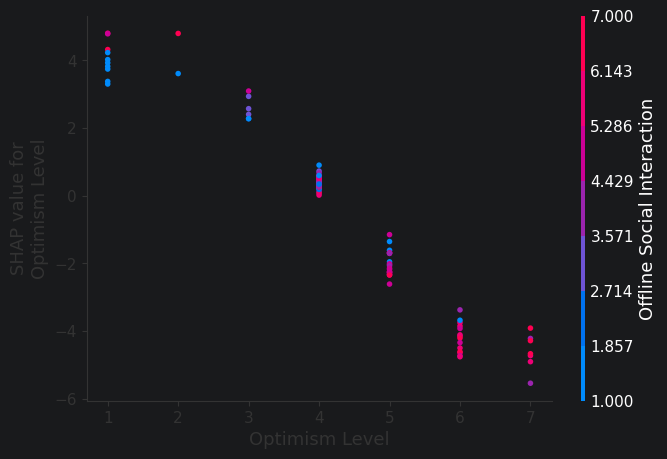

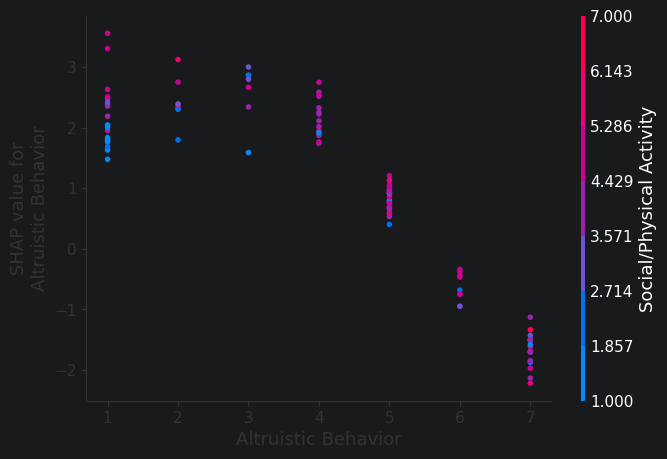

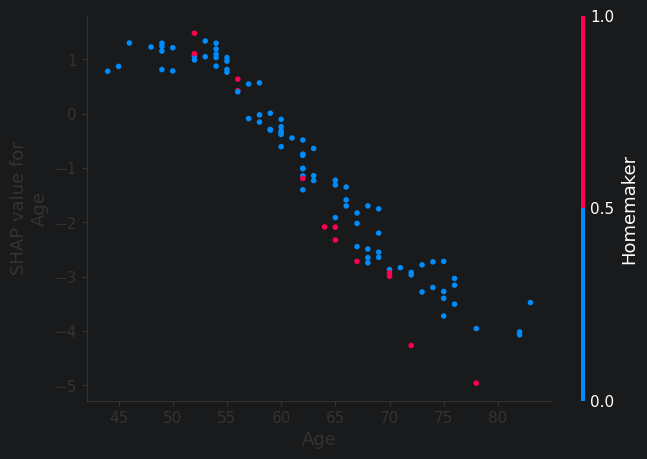

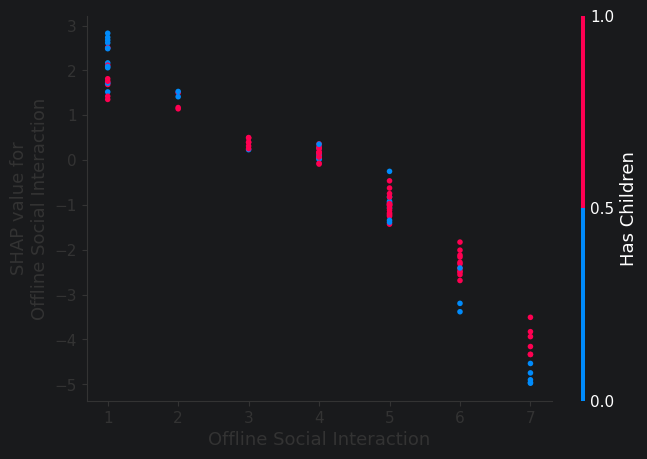

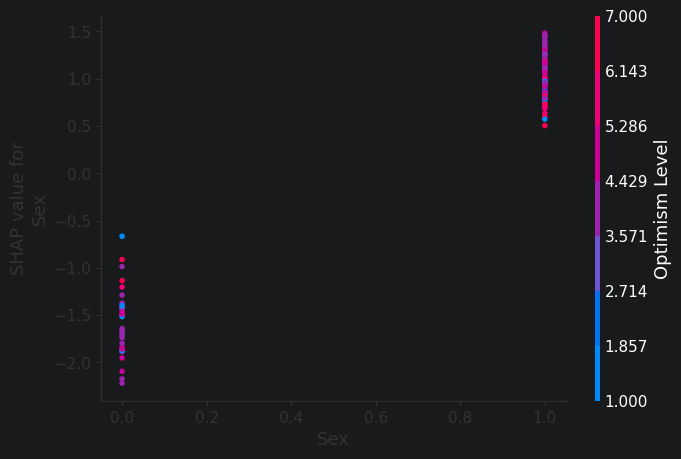

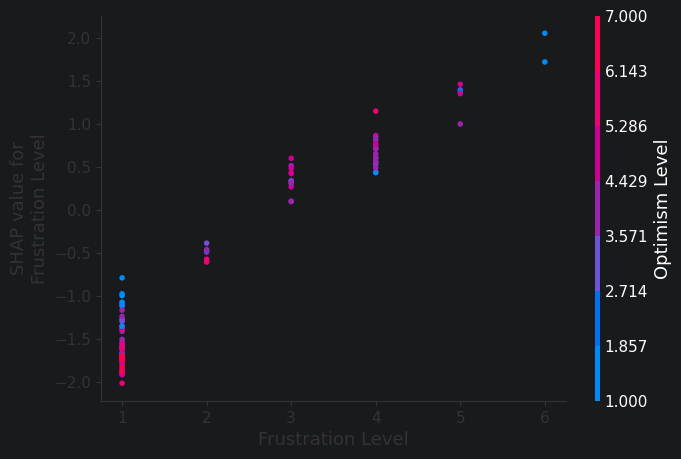

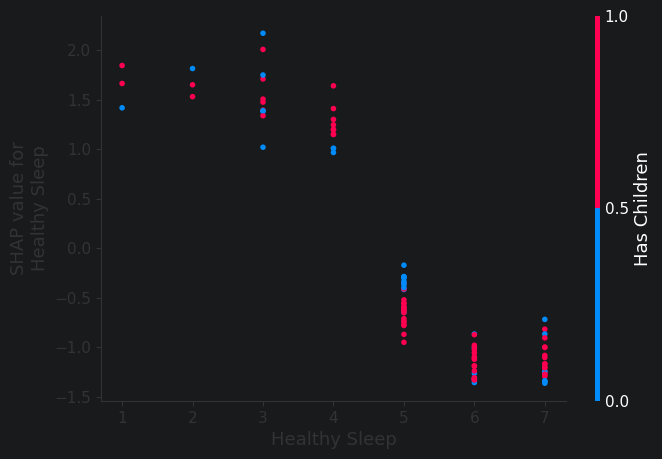

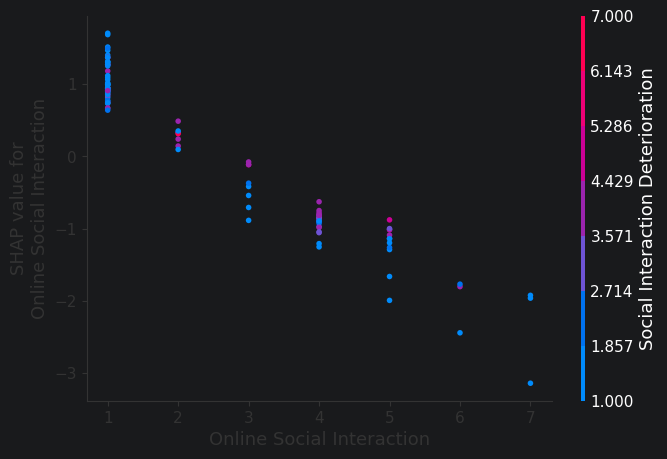

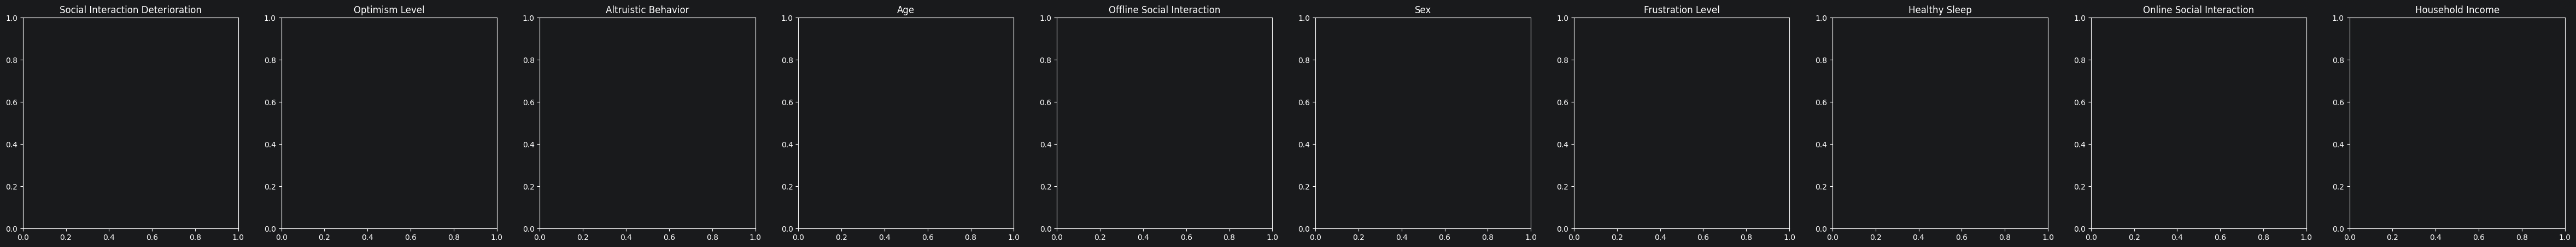

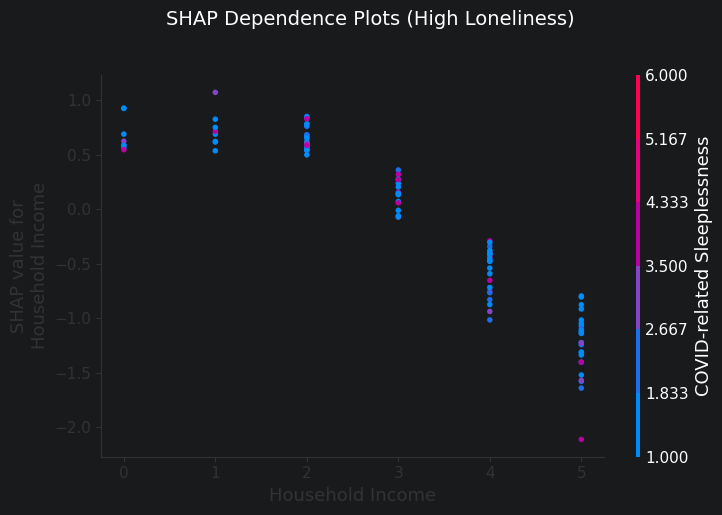

Saved: plots/shap/dependence_top_features.png


In [27]:
# Dependence plots for the top-N most important features (High Loneliness class).
# Increase N_TOP_FEATURES in the config cell to see more.
mean_abs_shap = np.abs(shap_values[1]).mean(axis=0)
top_indices = np.argsort(mean_abs_shap)[-N_TOP_FEATURES:][::-1]
top_feature_names = [display_names_list[j] for j in top_indices]

print(f"Top {N_TOP_FEATURES} features by mean |SHAP| (High Loneliness):")
for rank, (idx, name) in enumerate(zip(top_indices, top_feature_names), 1):
    print(f"  {rank}. {name} = {mean_abs_shap[idx]:.4f}")

fig, axes = plt.subplots(1, N_TOP_FEATURES, figsize=(6 * N_TOP_FEATURES, 5))
if N_TOP_FEATURES == 1:
    axes = [axes]

for ax, feat_idx, feat_name in zip(axes, top_indices, top_feature_names):
    plt.sca(ax)
    shap.dependence_plot(feat_idx, shap_values[1], X_explain,
                         feature_names=display_names_list,
                         interaction_index="auto", show=False)
    ax.set_title(feat_name)

plt.suptitle("SHAP Dependence Plots (High Loneliness)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("plots/shap/dependence_top_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/shap/dependence_top_features.png")

Sample 0: Predicted = High Loneliness
  P(Low)  = 0.143
  P(High) = 0.857


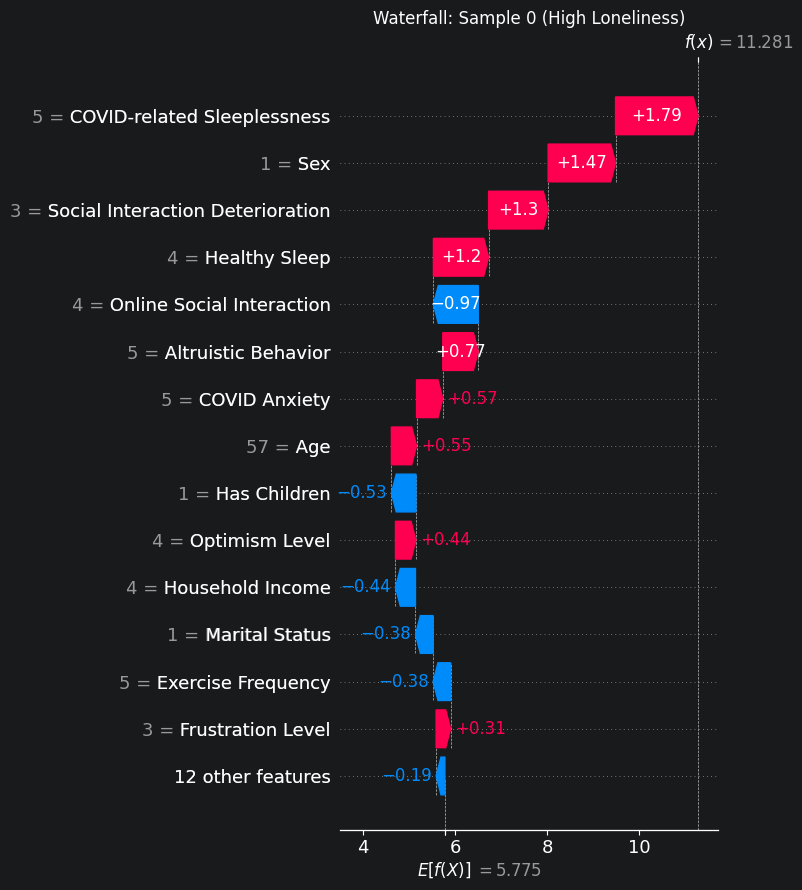

Saved: plots/shap/waterfall_sample_0.png


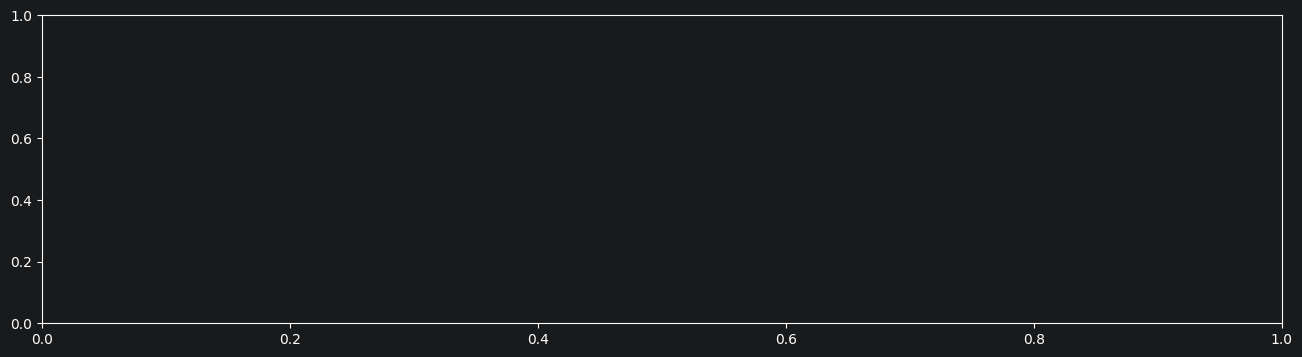

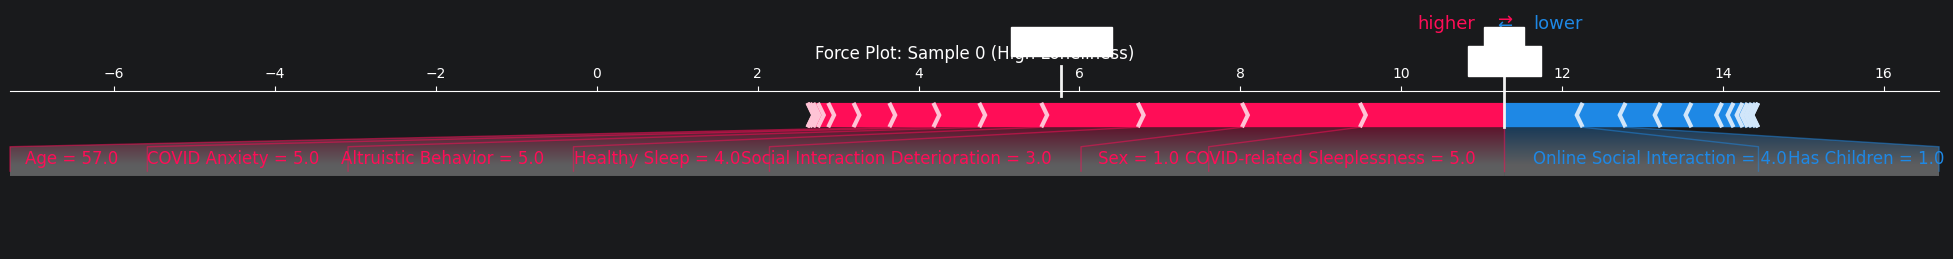

Saved: plots/shap/force_sample_0.png


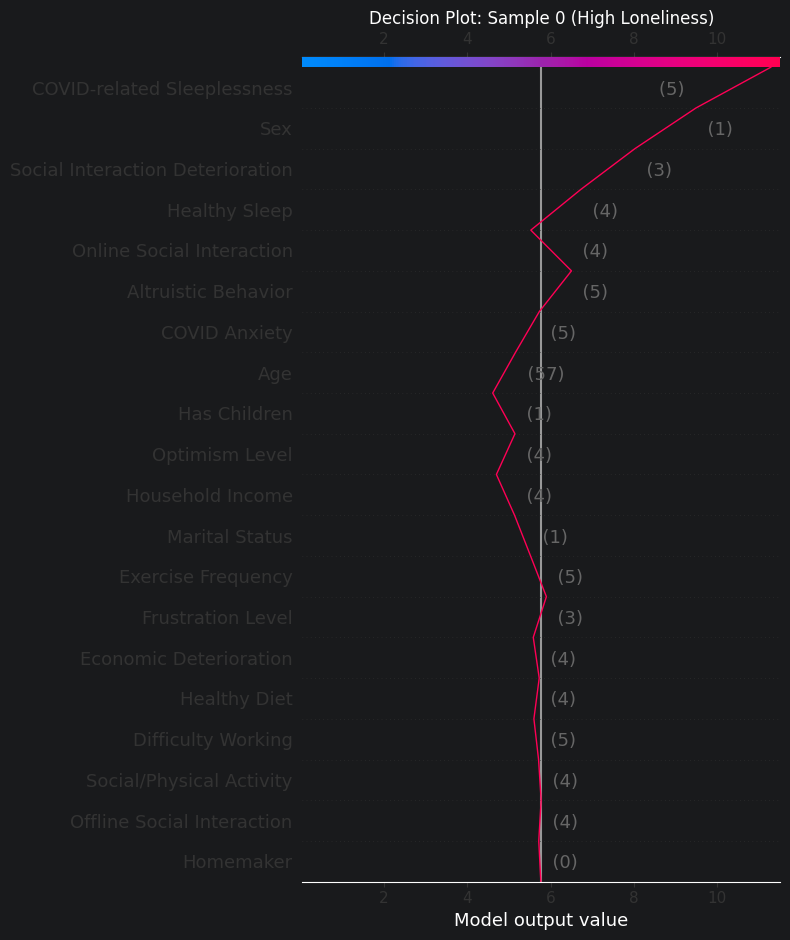

Saved: plots/shap/decision_sample_0.png


In [28]:
# --- Individual sample explanations ---
# Waterfall, force, and decision plots for a single sample.

sample_idx = 0                # <-- change to inspect a different sample
class_idx = 1                 # 0 = Low Loneliness, 1 = High Loneliness

pred = model.predict(X_explain.iloc[[sample_idx]])[0]
prob = model.predict_proba(X_explain.iloc[[sample_idx]])[0]
print(f"Sample {sample_idx}: Predicted = {class_names[pred]}")
print(f"  P(Low)  = {prob[0]:.3f}")
print(f"  P(High) = {prob[1]:.3f}")

# Handle expected_value: scalar (binary LGBMClassifier) or array
ev = shap_explainer.expected_value
if np.isscalar(ev) or (isinstance(ev, np.ndarray) and ev.ndim == 0):
    # Scalar → class 1 base value; class 0 is the negative
    base_values = [float(-ev), float(ev)]
else:
    base_values = [float(ev[0]), float(ev[1])]

# ---- Waterfall plot ----
shap_explanation = shap.Explanation(
    values=shap_values[class_idx][sample_idx],
    base_values=base_values[class_idx],
    data=X_explain.iloc[sample_idx].values,
    feature_names=display_names_list
)

fig, ax = plt.subplots(figsize=(10, 7))
shap.waterfall_plot(shap_explanation, show=False, max_display=15)
plt.title(f"Waterfall: Sample {sample_idx} ({class_names[class_idx]})")
plt.tight_layout()
plt.savefig(f"plots/shap/waterfall_sample_{sample_idx}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: plots/shap/waterfall_sample_{sample_idx}.png")

# ---- Force plot ----
shap.initjs()
fig, ax = plt.subplots(figsize=(16, 4))
shap.force_plot(base_values[class_idx],
                shap_values[class_idx][sample_idx, :],
                X_explain.iloc[sample_idx, :],
                feature_names=display_names_list,
                matplotlib=True, show=False)
plt.title(f"Force Plot: Sample {sample_idx} ({class_names[class_idx]})")
plt.tight_layout()
plt.savefig(f"plots/shap/force_sample_{sample_idx}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: plots/shap/force_sample_{sample_idx}.png")

# ---- Decision plot (shows cumulative SHAP contribution) ----
fig, ax = plt.subplots(figsize=(10, 8))
shap.decision_plot(base_values[class_idx],
                   shap_values[class_idx][sample_idx, :],
                   X_explain.iloc[sample_idx, :],
                   feature_names=display_names_list,
                   show=False)
plt.title(f"Decision Plot: Sample {sample_idx} ({class_names[class_idx]})")
plt.tight_layout()
plt.savefig(f"plots/shap/decision_sample_{sample_idx}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: plots/shap/decision_sample_{sample_idx}.png")

## 3.4 Multi-Sample Decision Plot

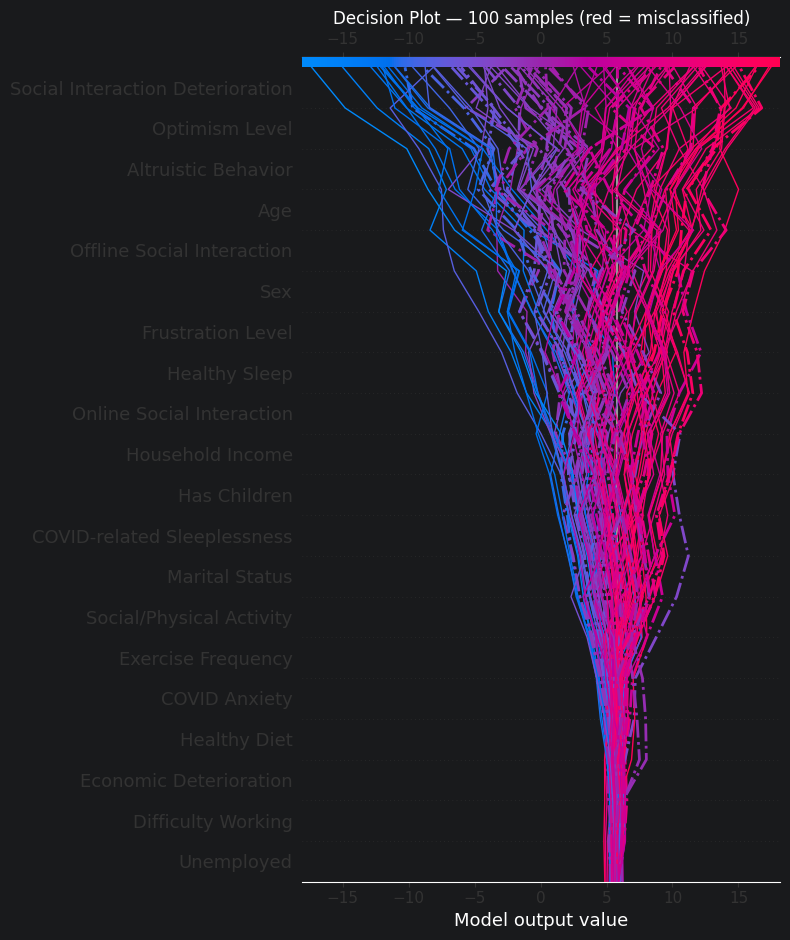

Saved: plots/shap/decision_all_samples.png
Misclassified: 30/100 (30.0%)


In [29]:
# Decision plot for all explained samples — misclassifications highlighted
y_explain = y_test.iloc[:N_SHAP_EXPLAIN].values
preds_explain = model.predict(X_explain)
misclassified = preds_explain != y_explain

fig, ax = plt.subplots(figsize=(10, 8))
shap.decision_plot(
    shap_explainer.expected_value,
    shap_values[1],
    X_explain,
    feature_names=display_names_list,
    highlight=misclassified,
    show=False
)
plt.title(f"Decision Plot — {N_SHAP_EXPLAIN} samples (red = misclassified)")
plt.tight_layout()
plt.savefig("plots/shap/decision_all_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/shap/decision_all_samples.png")

n_wrong = misclassified.sum()
print(f"Misclassified: {n_wrong}/{len(preds_explain)} ({100*n_wrong/len(preds_explain):.1f}%)")

# 4. Counterfactual Explanations

In [30]:
# Prepare DiceML data object
df_dice_train = X_train.copy()
df_dice_train[target_UCLA] = y_train.values

continuous_features = features_UCLA.copy()

permitted_range = {} # Binary features clamped to [0, 1]
binary_features = ["Sex_Male", "Is_Married", "Has_Child", "Income_Missing",
                   "Job_Employed", "Job_Homemaker", "Job_Student",
                   "Job_Unemployed", "Job_Other"]
for feat in features_UCLA:
    if feat in binary_features:
        permitted_range[feat] = [0, 1]
    else:
        permitted_range[feat] = [float(X_train[feat].min()),
                                 float(X_train[feat].max())]

dice_data = dice_ml.Data(
    dataframe=df_dice_train,
    continuous_features=continuous_features,
    outcome_name=target_UCLA
)

dice_model = dice_ml.Model(model=model, backend="sklearn")

# method="random" or "genetic" -> slower
dice_exp = dice_ml.Dice(dice_data, dice_model, method="random")

print("DiceML explainer initialized.")
print(f"Continuous features: {len(continuous_features)}")
print(f"Permitted ranges defined for {len(permitted_range)} features.")

DiceML explainer initialized.
Continuous features: 26
Permitted ranges defined for 26 features.


In [31]:
# Single-sample counterfactual
sample_idx = 0 # <-- change to inspect a different sample
test_instance = X_test.iloc[[sample_idx]]

pred = model.predict(test_instance)[0]
prob = model.predict_proba(test_instance)[0]

print(f"Original prediction: {class_names[pred]}")
print(f"Probabilities: Low={prob[0]:.3f}, High={prob[1]:.3f}")
print(f"\nFeature values (with category labels):")
for feat in features_UCLA:
    val = test_instance.iloc[0][feat]
    print(f"  {get_display_name(feat)}: {format_feature_value(feat, val)}")

Original prediction: High Loneliness
Probabilities: Low=0.143, High=0.857

Feature values (with category labels):
  Sex: Male
  Age: 57 years
  Marital Status: Married
  Has Children: Has Children
  Household Income: 6.0-7.9M JPY
  Income Missing: Income Reported
  Employed: Employed
  Homemaker: Not Homemaker
  Student: Not Student
  Unemployed: Not Unemployed
  Other Job: Not Other Job
  Social/Physical Activity: 4.0/7
  Exercise Frequency: 5.0/7
  Healthy Diet: 4.0/7
  Healthy Sleep: 4.0/7
  Offline Social Interaction: 4.0/7
  Online Social Interaction: 4.0/7
  Altruistic Behavior: 5.0/7
  Frustration Level: 3.0/7
  Optimism Level: 4.0/7
  COVID Anxiety: 5.0/7
  COVID-related Sleeplessness: 5.0/7
  Economic Deterioration: 4.0/7
  Social Interaction Deterioration: 3.0/7
  Difficulty Living: 5.0/7
  Difficulty Working: 5.0/7


In [32]:
# Generate counterfactuals
print(f"Generating {N_CF_PER_SAMPLE} counterfactuals...")
start_time = time.time()

dice_result = dice_exp.generate_counterfactuals(
    test_instance,
    total_CFs=N_CF_PER_SAMPLE,
    desired_class="opposite",
    permitted_range=permitted_range,
    random_seed=random_state
)

print(f"Generated in {format_time(time.time() - start_time)}")

Generating 5 counterfactuals...


100%|██████████| 1/1 [01:44<00:00, 104.53s/it]

Generated in 1m 44.53s


In [33]:
# Display with category labels
cf_df = dice_result.cf_examples_list[0].final_cfs_df
if cf_df is not None and len(cf_df) > 0:
    print(f"\n=== Counterfactual Changes (with labels) ===")
    original = test_instance.iloc[0]
    for cf_idx, (_, cf_row) in enumerate(cf_df.iterrows()):
        print(f"\nCounterfactual {cf_idx + 1}:")
        for feat in features_UCLA:
            orig_val = original[feat]
            cf_val = cf_row[feat]
            if abs(cf_val - orig_val) > 0.01:
                orig_label = format_feature_value(feat, orig_val)
                cf_label = format_feature_value(feat, cf_val)
                direction = "↑" if cf_val > orig_val else "↓"
                print(f"  {get_display_name(feat)}: {orig_label} → {cf_label} ({direction} {abs(cf_val - orig_val):.2f})")


=== Counterfactual Changes (with labels) ===

Counterfactual 1:
  Sex: Male → Female (↓ 1.00)
  COVID-related Sleeplessness: 5.0/7 → 2.0/7 (↓ 3.00)
  Social Interaction Deterioration: 3.0/7 → 2.0/7 (↓ 1.00)

Counterfactual 2:
  Age: 57 years → 83 years (↑ 26.00)
  Offline Social Interaction: 4.0/7 → 7.0/7 (↑ 3.00)

Counterfactual 3:
  Sex: Male → Female (↓ 1.00)
  Age: 57 years → 88 years (↑ 31.00)
  Social/Physical Activity: 4.0/7 → 6.0/7 (↑ 2.00)

Counterfactual 4:
  Age: 57 years → 88 years (↑ 31.00)
  Homemaker: Not Homemaker → Homemaker (↑ 1.00)
  Social Interaction Deterioration: 3.0/7 → 2.0/7 (↓ 1.00)

Counterfactual 5:
  Age: 57 years → 69 years (↑ 12.00)
  Other Job: Not Other Job → Other Job (↑ 1.00)
  Frustration Level: 3.0/7 → 1.0/7 (↓ 2.00)
  Social Interaction Deterioration: 3.0/7 → 1.0/7 (↓ 2.00)


In [34]:
# Save single-sample CF plot
fig, ax = plt.subplots(figsize=(12, 6))
if cf_df is not None and len(cf_df) > 0:
    changes_data = []
    for feat in features_UCLA:
        orig_val = original[feat]
        for cf_idx, (_, cf_row) in enumerate(cf_df.iterrows()):
            cf_val = cf_row[feat]
            if abs(cf_val - orig_val) > 0.01:
                changes_data.append({
                    "Feature": get_display_name(feat),
                    "CF": f"CF {cf_idx+1}",
                    "Change": cf_val - orig_val
                })
    if changes_data:
        changes_plot_df = pd.DataFrame(changes_data)
        fig = px.bar(changes_plot_df, x="Change", y="Feature", color="CF",
                     orientation="h", barmode="group",
                     title=f"Counterfactual Changes for Sample {sample_idx}")
        fig.update_layout(height=max(400, len(changes_plot_df["Feature"].unique()) * 30))
        fig.write_image(f"plots/counterfactuals/cf_sample_{sample_idx}.png", scale=2)
        fig.show()
        print(f"Saved: plots/counterfactuals/cf_sample_{sample_idx}.png")

Saved: plots/counterfactuals/cf_sample_0.png


## 4.1 Batch Counterfactuals


In [35]:
# Batch counterfactual generation
cf_results = []

print(f"Generating counterfactuals for {N_CF_SAMPLES} samples "
      f"({N_CF_PER_SAMPLE} CFs each)...")
start_time = time.time()

for idx in range(min(N_CF_SAMPLES, len(X_test))):
    instance = X_test.iloc[[idx]]
    original_pred = model.predict(instance)[0]

    try:
        cf = dice_exp.generate_counterfactuals(
            instance,
            total_CFs=N_CF_PER_SAMPLE,
            desired_class="opposite",
            permitted_range=permitted_range,
            random_seed=random_state
        )
        cf_df = cf.cf_examples_list[0].final_cfs_df
        if cf_df is not None and len(cf_df) > 0:
            cf_results.append({
                "sample_idx": idx,
                "original_pred": original_pred,
                "original_values": instance.iloc[0].to_dict(),
                "counterfactuals": cf_df.to_dict("records"),
                "n_counterfactuals": len(cf_df)
            })
            print(f"  Sample {idx}: {len(cf_df)} CFs "
                  f"(original: {class_names[original_pred]})")
        else:
            print(f"  Sample {idx}: No valid CFs found")
    except Exception as e:
        print(f"  Sample {idx}: Error — {e}")

elapsed = time.time() - start_time
print(f"\nDone in {format_time(elapsed)}. "
      f"{len(cf_results)}/{N_CF_SAMPLES} successful.")

Generating counterfactuals for 50 samples (5 CFs each)...


100%|██████████| 1/1 [01:43<00:00, 103.74s/it]


  Sample 0: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:45<00:00, 105.40s/it]


  Sample 1: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:51<00:00, 111.79s/it]


  Sample 2: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:30<00:00, 90.94s/it]


  Sample 3: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:38<00:00, 98.30s/it]


  Sample 4: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [02:01<00:00, 121.92s/it]


  Sample 5: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:32<00:00, 92.16s/it]


  Sample 6: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [02:08<00:00, 128.58s/it]


  Sample 7: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:39<00:00, 99.71s/it]


  Sample 8: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:31<00:00, 91.89s/it]


  Sample 9: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:53<00:00, 113.36s/it]


  Sample 10: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:51<00:00, 111.08s/it]


  Sample 11: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:39<00:00, 99.06s/it]


  Sample 12: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:31<00:00, 91.76s/it]


  Sample 13: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:53<00:00, 113.68s/it]


  Sample 14: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:31<00:00, 91.77s/it]


  Sample 15: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [02:29<00:00, 149.50s/it]


  Sample 16: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:31<00:00, 91.80s/it]


  Sample 17: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:31<00:00, 91.66s/it]


  Sample 18: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:38<00:00, 99.00s/it]


  Sample 19: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:53<00:00, 113.39s/it]


  Sample 20: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:31<00:00, 91.83s/it]


  Sample 21: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:53<00:00, 113.55s/it]


  Sample 22: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [02:07<00:00, 127.92s/it]


  Sample 23: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:31<00:00, 91.92s/it]


  Sample 24: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:32<00:00, 92.39s/it]


  Sample 25: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:40<00:00, 100.26s/it]


  Sample 26: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:40<00:00, 100.18s/it]


  Sample 27: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:39<00:00, 99.84s/it]


  Sample 28: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:31<00:00, 91.82s/it]


  Sample 29: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:32<00:00, 92.34s/it]


  Sample 30: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:32<00:00, 92.02s/it]


  Sample 31: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:39<00:00, 99.12s/it]


  Sample 32: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:31<00:00, 91.97s/it]


  Sample 33: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:31<00:00, 91.82s/it]


  Sample 34: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:31<00:00, 91.79s/it]


  Sample 35: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:31<00:00, 91.88s/it]


  Sample 36: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:31<00:00, 91.92s/it]


  Sample 37: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [02:58<00:00, 178.78s/it]


  Sample 38: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:39<00:00, 99.13s/it]


  Sample 39: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:31<00:00, 91.90s/it]


  Sample 40: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:31<00:00, 91.77s/it]


  Sample 41: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:32<00:00, 92.09s/it]


  Sample 42: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:31<00:00, 91.92s/it]


  Sample 43: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:32<00:00, 92.03s/it]


  Sample 44: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [02:30<00:00, 150.05s/it]


  Sample 45: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:39<00:00, 99.23s/it]


  Sample 46: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:31<00:00, 91.83s/it]


  Sample 47: 5 CFs (original: Low Loneliness)


100%|██████████| 1/1 [01:53<00:00, 113.71s/it]


  Sample 48: 5 CFs (original: High Loneliness)


100%|██████████| 1/1 [01:32<00:00, 92.09s/it]

  Sample 49: 5 CFs (original: Low Loneliness)

Done in 1h 31m 11.77s. 50/50 successful.


## 4.2 Counterfactual Feature Analysis



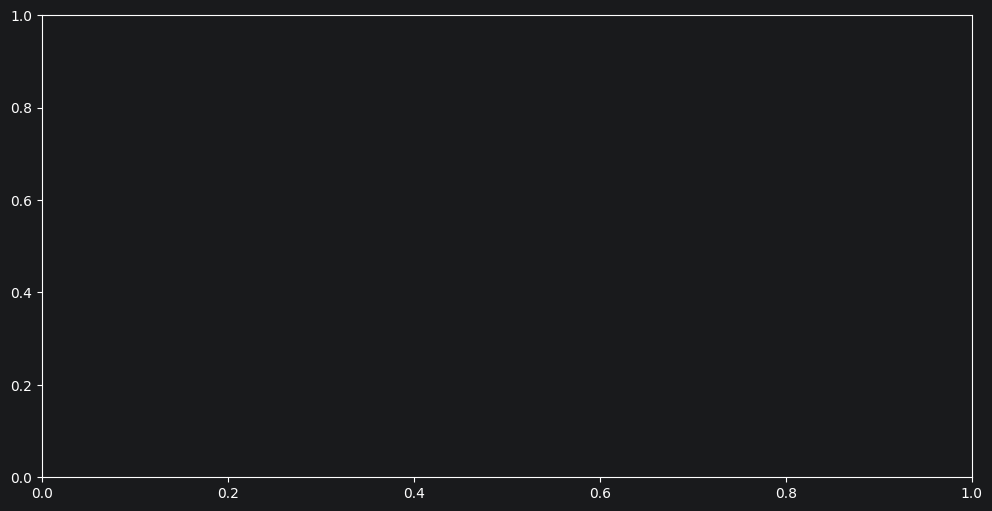

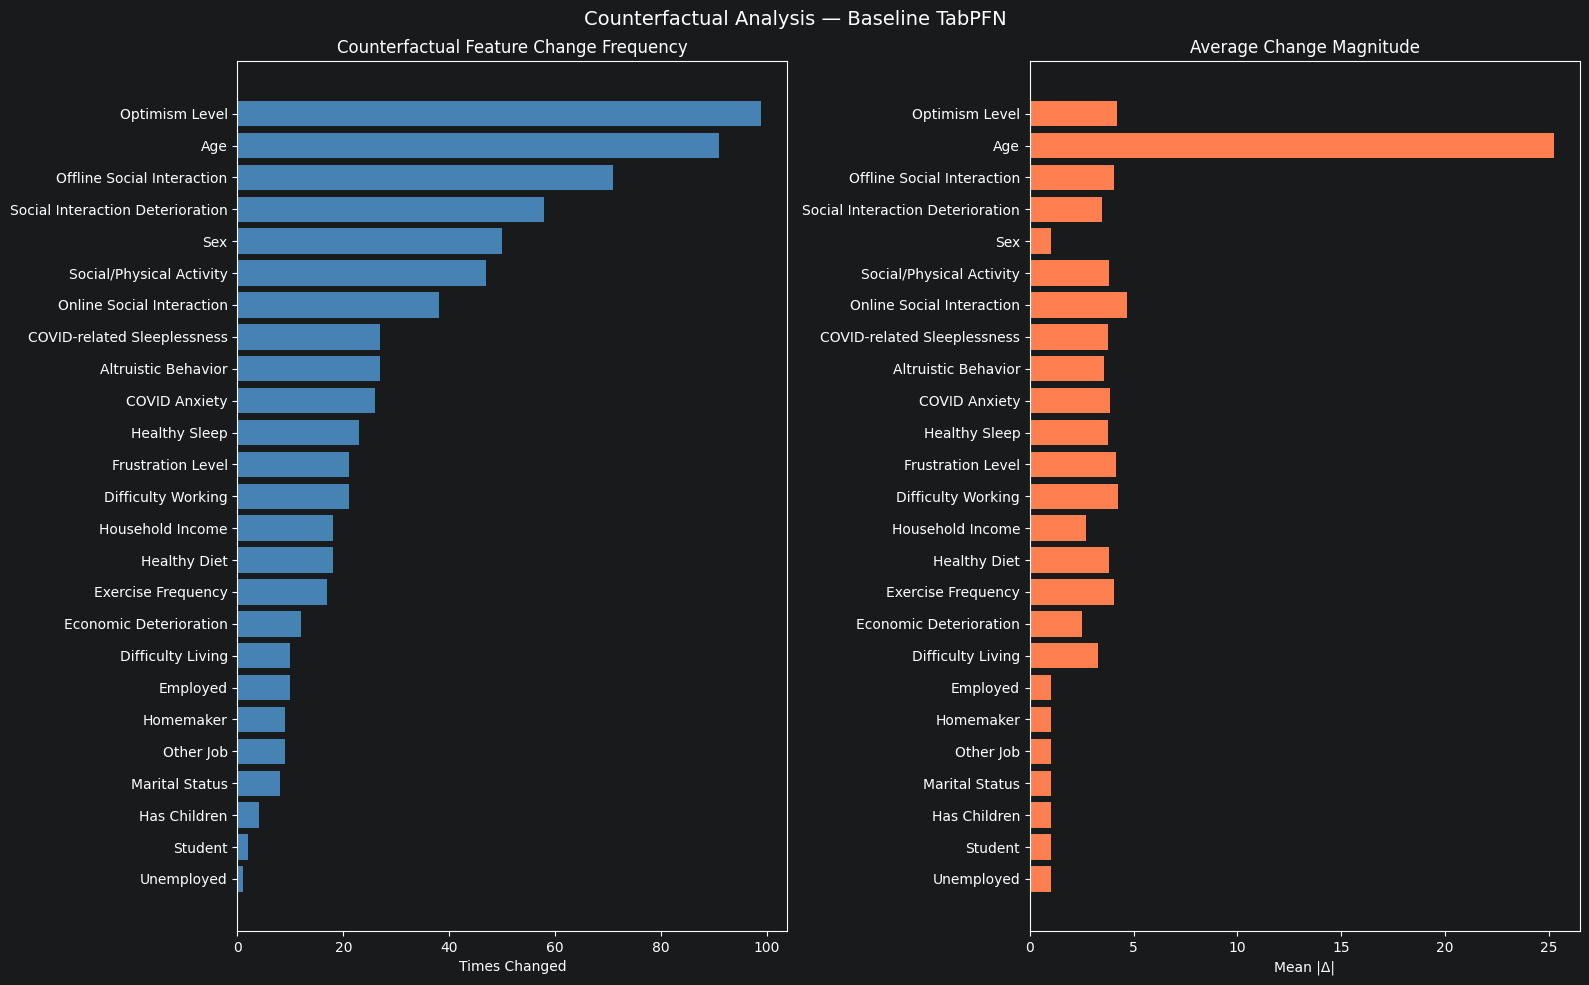

Saved: plots/counterfactuals/cf_feature_analysis.png


,Feature,Display Name,Change Count,Avg Magnitude,Dominant Direction
19,Optimism,Optimism Level,99,4.191919,increase
1,Age,Age,91,25.252747,increase
15,Interaction_Offline,Offline Social Interaction,71,4.056338,increase
23,Deterioration_Interact,Social Interaction Deterioration,58,3.482759,increase
0,Sex_Male,Sex,50,1.000000,decrease
11,Activity,Social/Physical Activity,47,3.829787,increase
16,Interaction_Online,Online Social Interaction,38,4.657895,increase
17,Altruistic,Altruistic Behavior,27,3.555556,increase
21,Covid_Sleepless,COVID-related Sleeplessness,27,3.740741,increase
20,Covid_Anxiety,COVID Anxiety,26,3.846154,increase


In [36]:
feature_change_counts = {feat: 0 for feat in features_UCLA}
feature_change_magnitudes = {feat: [] for feat in features_UCLA}
feature_change_directions = {feat: [] for feat in features_UCLA}

for result in cf_results:
    original = result["original_values"]
    for cf in result["counterfactuals"]:
        for feat in features_UCLA:
            if feat in cf and feat in original:
                diff = cf[feat] - original[feat]
                if abs(diff) > 0.01:
                    feature_change_counts[feat] += 1
                    feature_change_magnitudes[feat].append(abs(diff))
                    feature_change_directions[feat].append(
                        "increase" if diff > 0 else "decrease")

change_df = pd.DataFrame({
    "Feature": list(feature_change_counts.keys()),
    "Display Name": [get_display_name(f) for f in feature_change_counts.keys()],
    "Change Count": list(feature_change_counts.values()),
    "Avg Magnitude": [np.mean(v) if v else 0
                      for v in feature_change_magnitudes.values()],
    "Dominant Direction": [
        max(set(v), key=v.count) if v else "n/a"
        for v in feature_change_directions.values()
    ]
}).sort_values("Change Count", ascending=True)

change_df_nonzero = change_df[change_df["Change Count"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(change_df_nonzero) * 0.4)))

axes[0].barh(change_df_nonzero["Display Name"],
             change_df_nonzero["Change Count"], color="steelblue")
axes[0].set_title("Counterfactual Feature Change Frequency")
axes[0].set_xlabel("Times Changed")

axes[1].barh(change_df_nonzero["Display Name"],
             change_df_nonzero["Avg Magnitude"], color="coral")
axes[1].set_title("Average Change Magnitude")
axes[1].set_xlabel("Mean |Δ|")

plt.suptitle("Counterfactual Analysis — Baseline TabPFN", fontsize=14)
plt.tight_layout()
plt.savefig("plots/counterfactuals/cf_feature_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/counterfactuals/cf_feature_analysis.png")

display(change_df_nonzero.sort_values("Change Count", ascending=False))

# 5. SHAP vs Counterfactual Comparison


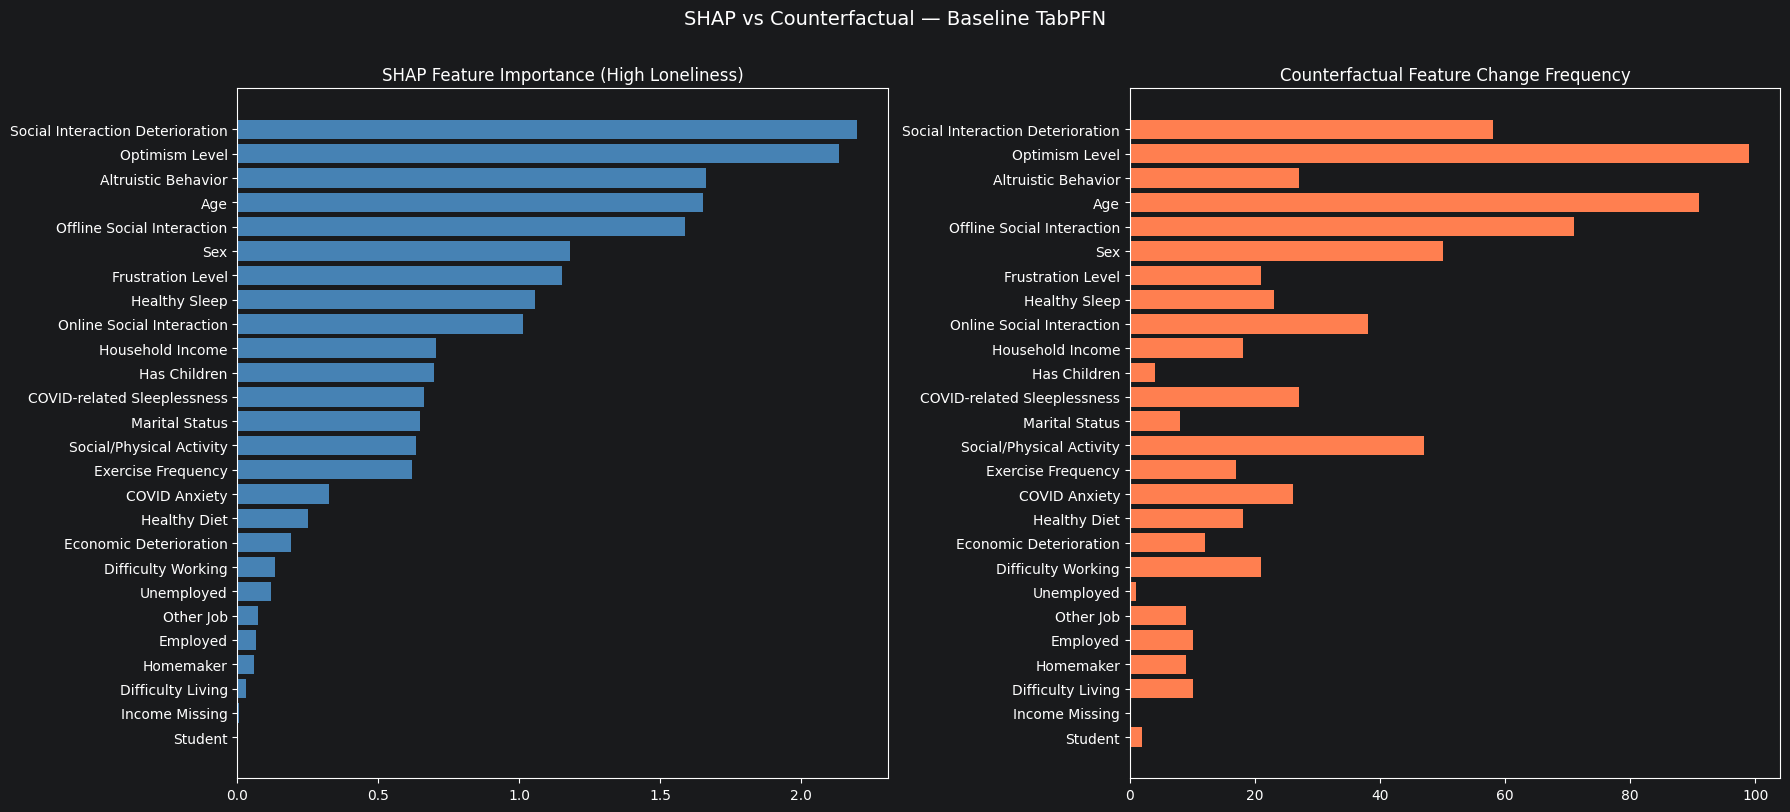

Saved: plots/shap_vs_counterfactual.png
Spearman rank correlation: ρ = 0.802, p = 0.0000
(High ρ means SHAP and counterfactuals agree on feature importance.)



,Feature,Display Name,SHAP Importance,Change Count
23,Deterioration_Interact,Social Interaction Deterioration,2.196277,58
19,Optimism,Optimism Level,2.133277,99
17,Altruistic,Altruistic Behavior,1.662775,27
1,Age,Age,1.650710,91
15,Interaction_Offline,Offline Social Interaction,1.587360,71
0,Sex_Male,Sex,1.179049,50
18,Frustration,Frustration Level,1.149835,21
14,Healthy_Sleep,Healthy Sleep,1.054609,23
16,Interaction_Online,Online Social Interaction,1.011882,38
4,Income,Household Income,0.704161,18


In [37]:
# SHAP importance (High Loneliness class)
class_idx = 1
shap_importance = np.abs(shap_values[class_idx]).mean(axis=0)
shap_df = pd.DataFrame({
    "Feature": features_list,
    "Display Name": get_display_names_list(features_list),
    "SHAP Importance": shap_importance
})

combined = shap_df.merge(
    change_df[["Feature", "Change Count"]], on="Feature", how="left"
).fillna(0)
combined = combined.sort_values("SHAP Importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].barh(combined["Display Name"], combined["SHAP Importance"],
             color="steelblue")
axes[0].set_title("SHAP Feature Importance (High Loneliness)")
axes[0].invert_yaxis()

axes[1].barh(combined["Display Name"], combined["Change Count"],
             color="coral")
axes[1].set_title("Counterfactual Feature Change Frequency")
axes[1].invert_yaxis()

plt.suptitle("SHAP vs Counterfactual — Baseline TabPFN",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("plots/shap_vs_counterfactual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/shap_vs_counterfactual.png")

from scipy.stats import spearmanr
rho, pval = spearmanr(combined["SHAP Importance"], combined["Change Count"])
print(f"Spearman rank correlation: ρ = {rho:.3f}, p = {pval:.4f}")
print("(High ρ means SHAP and counterfactuals agree on feature importance.)\n")

display(combined)

# 6. Save

In [38]:
# Save counterfactual results
with open("explainers/dice_results.pkl", "wb") as f:
    pickle.dump(cf_results, f)

# Save pre-computed counterfactuals in dashboard-friendly format
precomputed_cfs = {}
for result in cf_results:
    precomputed_cfs[result["sample_idx"]] = result["counterfactuals"]
with open("explainers/counterfactual_results.pkl", "wb") as f:
    pickle.dump(precomputed_cfs, f)

# Save test predictions for dashboard
y_pred_all = model.predict(X_test)
y_prob_all = model.predict_proba(X_test)[:, 1]
precomputed_preds = {"y_pred": y_pred_all, "y_prob": y_prob_all}
with open("artifacts/test_predictions.pkl", "wb") as f:
    pickle.dump(precomputed_preds, f)

# Save feature metadata
feature_info = {
    "features": features_UCLA,
    "target": target_UCLA,
    "cutoff": UCLA_cutoff,
    "class_names": class_names,
    "category_labels": CATEGORY_LABELS,
    "display_names": FEATURE_DISPLAY_NAMES,
    "likert_features": LIKERT_FEATURES,
}
with open("explainers/feature_info.pkl", "wb") as f:
    pickle.dump(feature_info, f)

print("All artifacts saved:")
print("  - explainers/dice_results.pkl")
print("  - explainers/counterfactual_results.pkl")
print("  - explainers/shap_values_test.pkl")
print("  - explainers/shap_expected_value.pkl")
print("  - explainers/feature_info.pkl")
print("  - artifacts/X_train.csv, X_test.csv, y_train.csv, y_test.csv")
print("  - artifacts/X_explain.csv")
print("  - artifacts/test_predictions.pkl")
print("  - plots/ (all SHAP and counterfactual plots)")

All artifacts saved:
  - explainers/dice_results.pkl
  - explainers/counterfactual_results.pkl
  - explainers/shap_values_test.pkl
  - explainers/shap_expected_value.pkl
  - explainers/feature_info.pkl
  - artifacts/X_train.csv, X_test.csv, y_train.csv, y_test.csv
  - artifacts/X_explain.csv
  - artifacts/test_predictions.pkl
  - plots/ (all SHAP and counterfactual plots)
